In [1]:
%load_ext autoreload
%autoreload 2

import pandas as pd
import os
# only load this one time per session
if 'NOTEBOOK_INITIALIZED' not in globals():
    os.chdir(os.path.dirname(os.path.abspath('.')))
    NOTEBOOK_INITIALIZED = True


import src.utils as utils
import src.config as config
import src.haplosaurus as hs
import src.vep_pipeline as vp
import src.vep_analysis as va
import src.vep_metrics as vm
import src.proteingym as pg 
import src.onekg as og
import src.colabfold as cf
import src.unitprot as up



import matplotlib.pyplot as plt
import seaborn as sns
import pooch
from tqdm import tqdm
import polars as pl
import numpy as np  

pd.set_option('display.max_columns', None)

/home/schilder/.conda/envs/esm2/lib/python3.12/site-packages/Bio/Application/__init__.py:39: BiopythonDeprecationWarning: The Bio.Application modules and modules relying on it have been deprecated.

Due to the on going maintenance burden of keeping command line application
wrappers up to date, we have decided to deprecate and eventually remove these
modules.

We instead now recommend building your command line and invoking it directly
with the subprocess module.
  warnings.warn(


In [19]:
study_index = pd.read_json("https://ftp.ebi.ac.uk/pub/databases/opentargets/genetics/22.02.01/lut/study-index/part-00000-2e5fae34-19dc-4dff-8f46-9d8a6fc11895-c000.json", lines=True)
study_index.head()


,study_id,pub_date,pub_author,trait_reported,ancestry_initial,ancestry_replication,n_initial,n_replication,n_cases,num_assoc_loci,has_sumstats,source,trait_efos,trait_category
0,FINNGEN_R5_AB1_AMOEBIASIS,2021-5-11,FINNGEN_R5,Amoebiasis,[European=197385],[],197385,0,87,0,True,FINNGEN,[EFO_0007144],infectious disease
1,FINNGEN_R5_AB1_ANOGENITAL_HERPES_SIMPLEX,2021-5-11,FINNGEN_R5,Anogenital herpesviral [herpes simplex] infection,[European=213843],[],213843,0,891,0,True,FINNGEN,[EFO_0007282],infectious disease
2,FINNGEN_R5_AB1_ARTHROPOD,2021-5-11,FINNGEN_R5,Arthropod-borne viral fevers and viral haemorr...,[European=218792],[],218792,0,1450,0,True,FINNGEN,"[MONDO_0018087, EFO_0000763]",infectious disease
3,FINNGEN_R5_AB1_ASPERGILLOSIS,2021-5-11,FINNGEN_R5,Aspergillosis,[European=214903],[],214903,0,87,0,True,FINNGEN,[EFO_0007157],infectious disease
4,FINNGEN_R5_AB1_ATYPICAL_CNS_VIRUS,2021-5-11,FINNGEN_R5,Atypical virus infections of central nervous s...,[European=217783],[],217783,0,146,0,True,FINNGEN,[MONDO_0024318],infectious disease
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1263,FINNGEN_R5_H7_SEVVISIMPMONOC,2021-5-11,FINNGEN_R5,"""Severe visual impairment, monocular""",[European=210946],[],210946,0,80,0,True,FINNGEN,[MONDO_0001941],disease of visual system
1264,FINNGEN_R5_H7_STENOLACRI,2021-5-11,FINNGEN_R5,Stenosis and insufficiency of lacrimal passages,[European=204549],[],204549,0,1318,0,True,FINNGEN,[HP_0000614],phenotype
1265,FINNGEN_R5_H7_STRABISMUS,2021-5-11,FINNGEN_R5,Strabismus,[European=218792],[],218792,0,4620,0,True,FINNGEN,[HP_0000486],phenotype
1266,FINNGEN_R5_H7_STRABNAS,2021-5-11,FINNGEN_R5,Other specified and unspecified strabismus,[European=211071],[],211071,0,140,0,True,FINNGEN,[HP_0000486],phenotype


In [22]:
v2g_scored = pd.read_parquet("https://ftp.ebi.ac.uk/pub/databases/opentargets/genetics/latest/v2g_scored/part-00000-f45b4766-6956-4139-be15-36bd714f7d47-c000.snappy.parquet")
print(v2g_scored.shape)
v2g_scored.head()

(1000000, 25)


,chr_id,position,ref_allele,alt_allele,gene_id,feature,type_id,source_id,fpred_labels,fpred_scores,fpred_max_label,fpred_max_score,qtl_beta,qtl_se,qtl_pval,qtl_score,interval_score,qtl_score_q,interval_score_q,d,distance_score,distance_score_q,overall_score,source_list,source_score_list
0,1,10291,C,CT,ENSG00000284733,unspecified,distance,canonical_tss,[],[],None,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,441387.0,0.000002,0.1,0.006640,[canonical_tss],[0.1]
1,1,54380,T,C,ENSG00000186092,unspecified,distance,canonical_tss,[],[],None,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,11039.0,0.000091,1.0,0.066398,[canonical_tss],[1.0]
2,1,55285,T,C,ENSG00000186092,unspecified,distance,canonical_tss,[],[],None,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,10134.0,0.000099,1.0,0.066398,[canonical_tss],[1.0]
3,1,63325,T,C,ENSG00000284733,unspecified,distance,canonical_tss,[],[],None,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,388353.0,0.000003,0.2,0.013280,[canonical_tss],[0.2]
4,1,72573,G,T,ENSG00000186092,unspecified,distance,canonical_tss,[],[],None,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,7154.0,0.000140,1.0,0.066398,[canonical_tss],[1.0]


In [21]:
d2v2g_scored = pd.read_parquet("https://ftp.ebi.ac.uk/pub/databases/opentargets/genetics/latest/d2v2g_scored/part-00000-4496e3f4-9708-4c3a-a769-93d95c79b892-c000.snappy.parquet")
print(d2v2g_scored.shape)
d2v2g_scored.head()

(1000000, 64)


,tag_chrom,tag_pos,tag_ref,tag_alt,gene_id,study_id,source,pmid,pub_date,pub_journal,pub_title,pub_author,has_sumstats,trait_reported,trait_efos,ancestry_initial,ancestry_replication,n_initial,n_replication,n_cases,trait_category,num_assoc_loci,lead_chrom,lead_pos,lead_ref,lead_alt,overall_r2,AFR_1000G_prop,AMR_1000G_prop,EAS_1000G_prop,EUR_1000G_prop,SAS_1000G_prop,log10_ABF,posterior_prob,odds_ratio,oddsr_ci_lower,oddsr_ci_upper,direction,beta,beta_ci_lower,beta_ci_upper,pval_mantissa,pval_exponent,pval,feature,type_id,source_id,fpred_labels,fpred_scores,fpred_max_label,fpred_max_score,qtl_beta,qtl_se,qtl_pval,qtl_score,interval_score,qtl_score_q,interval_score_q,d,distance_score,distance_score_q,overall_score,source_list,source_score_list
0,1,901544,G,A,ENSG00000175756,GCST90025945,GCST,PMID:34226706,2021-07-05,Nat Genet,Whole-exome imputation within UK Biobank power...,Barton AR,True,Cystatin C levels,[EFO_0004617],[European=437846],[],437846,NaN,NaN,measurement,607,1,922671,C,T,0.517138,0.0,0.0,0.0,1.0,0.0,NaN,NaN,NaN,NaN,NaN,-,-0.016747,-0.021301,-0.012194,7.0,-15,7.000000e-15,unspecified,distance,canonical_tss,[],[],None,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,473663.0,0.000002,0.1,0.006640,[canonical_tss],[0.1]
1,1,903007,T,C,ENSG00000078808,GCST90025945,GCST,PMID:34226706,2021-07-05,Nat Genet,Whole-exome imputation within UK Biobank power...,Barton AR,True,Cystatin C levels,[EFO_0004617],[European=437846],[],437846,NaN,NaN,measurement,607,1,922671,C,T,0.517138,0.0,0.0,0.0,1.0,0.0,NaN,NaN,NaN,NaN,NaN,-,-0.016747,-0.021301,-0.012194,7.0,-15,7.000000e-15,unspecified,distance,canonical_tss,[],[],None,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,329024.0,0.000003,0.3,0.019920,[canonical_tss],[0.3]
2,1,911848,C,T,ENSG00000188290,GCST90025945,GCST,PMID:34226706,2021-07-05,Nat Genet,Whole-exome imputation within UK Biobank power...,Barton AR,True,Cystatin C levels,[EFO_0004617],[European=437846],[],437846,NaN,NaN,measurement,607,1,922671,C,T,0.726337,0.0,0.0,0.0,1.0,0.0,NaN,NaN,NaN,NaN,NaN,-,-0.016747,-0.021301,-0.012194,7.0,-15,7.000000e-15,CEDAR-NEUTROPHIL_CD15,eqtl,eqtl,[],[],None,NaN,0.324670,0.058582,7.186620e-08,7.143475,NaN,0.4,NaN,NaN,NaN,NaN,0.146076,"[canonical_tss, eqtl]","[0.8, 0.7]"
3,1,911848,C,T,ENSG00000188290,GCST90025945,GCST,PMID:34226706,2021-07-05,Nat Genet,Whole-exome imputation within UK Biobank power...,Barton AR,True,Cystatin C levels,[EFO_0004617],[European=437846],[],437846,NaN,NaN,measurement,607,1,922671,C,T,0.726337,0.0,0.0,0.0,1.0,0.0,NaN,NaN,NaN,NaN,NaN,-,-0.016747,-0.021301,-0.012194,7.0,-15,7.000000e-15,unspecified,distance,canonical_tss,[],[],None,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,88324.0,0.000011,0.8,0.146076,"[canonical_tss, eqtl]","[0.8, 0.7]"
4,1,911848,C,T,ENSG00000188290,GCST90025945,GCST,PMID:34226706,2021-07-05,Nat Genet,Whole-exome imputation within UK Biobank power...,Barton AR,True,Cystatin C levels,[EFO_0004617],[European=437846],[],437846,NaN,NaN,measurement,607,1,922671,C,T,0.726337,0.0,0.0,0.0,1.0,0.0,NaN,NaN,NaN,NaN,NaN,-,-0.016747,-0.021301,-0.012194,7.0,-15,7.000000e-15,eQTLGen-UBERON_0000178,eqtl,eqtl,[],[],None,NaN,0.172752,0.014979,8.974500e-31,30.046990,NaN,0.7,NaN,NaN,NaN,NaN,0.146076,"[canonical_tss, eqtl]","[0.8, 0.7]"


In [23]:
v2d = pd.read_parquet("https://ftp.ebi.ac.uk/pub/databases/opentargets/genetics/latest/v2d/part-00000-10068dba-939e-4873-be35-780fc4b12fcc-c000.snappy.parquet")
print(v2d.shape)
v2d.head()

(225545, 44)


,study_id,lead_chrom,lead_pos,lead_ref,lead_alt,direction,beta,beta_ci_lower,beta_ci_upper,odds_ratio,oddsr_ci_lower,oddsr_ci_upper,pval_mantissa,pval_exponent,pval,ancestry_initial,ancestry_replication,n_cases,n_initial,n_replication,pmid,pub_author,pub_date,pub_journal,pub_title,has_sumstats,num_assoc_loci,source,trait_reported,trait_efos,trait_category,tag_chrom,tag_pos,tag_ref,tag_alt,overall_r2,pics_95perc_credset,AFR_1000G_prop,AMR_1000G_prop,EAS_1000G_prop,EUR_1000G_prop,SAS_1000G_prop,log10_ABF,posterior_prob
0,GCST006585_950,1,1008088,T,C,+,0.735542,0.530600,0.940484,NaN,NaN,NaN,2.00000,-12,2.000000e-12,[European=3200],[],NaN,3200,NaN,PMID:30072576,Emilsson V,2018-08-02,Science,Co-regulatory networks of human serum proteins...,False,1,GCST,"Blood protein levels [ISG15, 14151_4_3]",[EFO_0007937],measurement,1,978812,G,C,0.595703,False,0.0,0.0,0.000000,1.000000,0.0,NaN,NaN
1,NEALE2_20003_1140867876,1,1010747,GT,G,-,NaN,NaN,NaN,0.346424,0.237266,0.505801,4.02417,-8,4.024170e-08,[European=361141],[],491.0,361141,0.0,None,UKB Neale v2,2018-08-01,None,None,True,6,NEALE,Prozac 20mg capsule | treatment/medication code,[EFO_0007010],measurement,1,978812,G,C,NaN,None,NaN,NaN,NaN,NaN,NaN,4.345352,0.00226
2,GCST90087821,1,1009731,C,T,+,0.707278,0.556401,0.858155,NaN,NaN,NaN,4.00000,-20,4.000000e-20,[European=5366],[],NaN,5366,NaN,PMID:35078996,Gudjonsson A,2022-01-25,Nat Commun,A genome-wide association study of serum prote...,False,2,GCST,Serum levels of protein ISG15,[EFO_0007937],measurement,1,978812,G,C,0.579132,False,0.0,0.0,0.000000,1.000000,0.0,NaN,NaN
3,GCST90095130,1,994997,C,T,+,5.840000,3.882404,7.797596,NaN,NaN,NaN,5.00000,-9,5.000000e-09,[European=33748],[],NaN,33748,NaN,PMID:34910505,van der Meer D,2021-12-15,Sci Adv,The genetic architecture of human cortical fol...,False,669,GCST,Vertex-wise cortical surface area,[EFO_0010736],measurement,1,986629,G,A,0.942542,True,0.0,0.0,0.000000,1.000000,0.0,NaN,NaN
4,GCST90018954,1,993036,G,A,+,0.015400,0.010211,0.020589,NaN,NaN,NaN,6.00000,-9,6.000000e-09,"[European=344104, East Asian=133471]",[],NaN,477575,NaN,PMID:34594039,Sakaue S,2021-09-30,Nat Genet,A cross-population atlas of genetic associatio...,False,305,GCST,Gamma glutamyl transpeptidase,[EFO_0004532],measurement,1,986629,G,A,0.910355,True,0.0,0.0,0.279477,0.720523,0.0,NaN,NaN


In [16]:
vep_files = va.list_vep_files(as_df=True)
vep_files.head()

No save_dir provided, using: /home/schilder/projects/data/1KG/vep


Finding VEP files:   0%|          | 0/1 [00:00<?, ?it/s]

Found 681512 parquet files in /home/schilder/projects/data/1KG/vep
Unique values:
>> model_location: 7
scoring_strategy: 3
variant_set: 1
haplotype: 85106
protein: 2142


,file,protein,haplotype,variant_set,model_location,scoring_strategy
0,/home/schilder/projects/data/1KG/vep/esm2_t12_...,NP_055800.2,ENSP00000382271:REF,clinical_ProteinGym_substitutions,esm2_t12_35M_UR50D,wt-marginals
1,/home/schilder/projects/data/1KG/vep/esm2_t12_...,NP_055800.2,ENSP00000382271:REF,clinical_ProteinGym_substitutions,esm2_t12_35M_UR50D,masked-marginals
2,/home/schilder/projects/data/1KG/vep/esm2_t12_...,NP_055800.2,ENSP00000382271:54S>L,clinical_ProteinGym_substitutions,esm2_t12_35M_UR50D,wt-marginals
3,/home/schilder/projects/data/1KG/vep/esm2_t12_...,NP_055800.2,ENSP00000382271:54S>L,clinical_ProteinGym_substitutions,esm2_t12_35M_UR50D,masked-marginals
4,/home/schilder/projects/data/1KG/vep/esm2_t12_...,NP_055800.2,ENSP00000382271:914L>V,clinical_ProteinGym_substitutions,esm2_t12_35M_UR50D,wt-marginals


In [18]:
refseq_id = 'NP_009225.1'
vep_df = va.merge_vep(
    scoring_strategy=["masked-marginals"],
    vep_files=vep_files.loc[(vep_files['model_location']=="esm2_t33_650M_UR50D") & (vep_files['protein']==refseq_id)]
    )
vep_df["HGNC"] = vep_df["GENEINFO"].str.split(":").str[0] 
vep_df.head()

No save_dir provided, using: /home/schilder/projects/data/1KG/vep
Found 109 masked-marginals parquet files


Reading files:   0%|          | 0/109 [00:00<?, ?it/s]

Concatenating VEP dataframes
Loading ==> /home/schilder/projects/data/haplosaurus/tx_id_map.pkl


Loading '/home/schilder/projects/data/haplosaurus/tx_id_map.pkl': 100%|██████████| 1.70M/1.70M [00:00<00:00, 2.14GB/s]


VEP dataframe shape: (49704, 72)


,haplotype,protein,protein_sequence,mutant,mutated_sequence,DMS_bin_score,VEP,scoring_strategy,is_ref,model_location,variant_set,ENSP,ENST,mutant_in_haplotype,#CHROM,POS,ID,REF,ALT,QUAL,FILTER,#Uploaded_variation,Location,Allele,Gene,Feature,Feature_type,Consequence,cDNA_position,CDS_position,Protein_position,Amino_acids,Codons,Existing_variation,IMPACT,DISTANCE,STRAND,FLAGS,REFSEQ_MATCH,REFSEQ_OFFSET,GIVEN_REF,USED_REF,BAM_EDIT,HGVSc,HGVSp,HGVS_OFFSET,AF_ESP,AF_EXAC,ALLELEID,CLNDISDB,CLNDN,CLNHGVS,CLNREVSTAT,CLNSIG,CLNSIGCONF,CLNVC,CLNVCSO,GENEINFO,MC,ORIGIN,RS,AF_TGP,CLNVI,CLNDISDBINCL,CLNDNINCL,CLNSIGINCL,EVH_epistatic,EVH_independent,ESM1V_ensemble_mean,Tranception,model_count,clinsig,HGNC
0,ENSP00000350283:1028R>H,NP_009225.1,MDLSALRVEEVQNVINAMQKILECPICLELIKEPVSTKCDHIFCKF...,H1860Q,MDLSALRVEEVQNVINAMQKILECPICLELIKEPVSTKCDHIFCKF...,Benign,0.639376,masked-marginals,False,esm2_t33_650M_UR50D,clinical_ProteinGym_substitutions,ENSP00000350283,ENST00000357654,False,17,43045690,1748423,G,T,.,PASS,1748423,17:43045690,T,672,NM_007294.4,Transcript,missense_variant,5693,5580,1860,H/Q,caC/caA,-,MODERATE,-,-1,-,-,-,G,G,-,NM_007294.4:c.5580C>A,NP_009225.1:p.His1860Gln,-,NaN,NaN,1806671,"MONDO:MONDO:0015356,MeSH:D009386,MedGen:C00276...",Hereditary_cancer-predisposing_syndrome,NC_000017.11:g.43045690G>T,"criteria_provided,_single_submitter",Likely_benign,NaN,single_nucleotide_variant,SO:0001483,BRCA1:672,"SO:0001583|missense_variant,SO:0001619|non-cod...",1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.632517,NaN,5,likely_benign,BRCA1
1,ENSP00000350283:1028R>H,NP_009225.1,MDLSALRVEEVQNVINAMQKILECPICLELIKEPVSTKCDHIFCKF...,P1859R,MDLSALRVEEVQNVINAMQKILECPICLELIKEPVSTKCDHIFCKF...,Benign,-1.005851,masked-marginals,False,esm2_t33_650M_UR50D,clinical_ProteinGym_substitutions,ENSP00000350283,ENST00000357654,False,17,43045694,55634,G,C,.,PASS,55634,17:43045694,C,672,NM_007294.4,Transcript,missense_variant,5689,5576,1859,P/R,cCc/cGc,-,MODERATE,-,-1,-,-,-,G,G,-,NM_007294.4:c.5576C>G,NP_009225.1:p.Pro1859Arg,-,NaN,0.00002,70301,"MedGen:CN517202|MONDO:MONDO:0015356,MeSH:D0093...",not_provided|Hereditary_cancer-predisposing_sy...,NC_000017.11:g.43045694G>C,reviewed_by_expert_panel,Benign,NaN,single_nucleotide_variant,SO:0001483,BRCA1:672,"SO:0001583|missense_variant,SO:0001619|non-cod...",1,80357322,NaN,BRCA1-HCI:BRCA1_00098|ClinGen:CA003729,NaN,NaN,NaN,NaN,NaN,-0.490676,NaN,5,benign,BRCA1
2,ENSP00000350283:1028R>H,NP_009225.1,MDLSALRVEEVQNVINAMQKILECPICLELIKEPVSTKCDHIFCKF...,I1858L,MDLSALRVEEVQNVINAMQKILECPICLELIKEPVSTKCDHIFCKF...,Benign,0.775333,masked-marginals,False,esm2_t33_650M_UR50D,clinical_ProteinGym_substitutions,ENSP00000350283,ENST00000357654,False,17,43045698,183951,T,G,.,PASS,183951,17:43045698,G,672,NM_007294.4,Transcript,missense_variant,5685,5572,1858,I/L,Atc/Ctc,-,MODERATE,-,-1,-,-,-,T,T,-,NM_007294.4:c.5572A>C,NP_009225.1:p.Ile1858Leu,-,NaN,0.00006,184864,"MONDO:MONDO:0015356,MeSH:D009386,MedGen:C00276...",Hereditary_cancer-predisposing_syndrome|not_sp...,NC_000017.11:g.43045698T>G,reviewed_by_expert_panel,Benign,NaN,single_nucleotide_variant,SO:0001483,BRCA1:672,"SO:0001583|missense_variant,SO:0001619|non-cod...",1,765656957,NaN,BRCA1-HCI:BRCA1_00097|ClinGen:CA003726,NaN,NaN,NaN,NaN,NaN,0.791910,NaN,5,benign,BRCA1
3,ENSP00000350283:1028R>H,NP_009225.1,MDLSALRVEEVQNVINAMQKILECPICLELIKEPVSTKCDHIFCKF...,P1856S,MDLSALRVEEVQNVINAMQKILECPICLELIKEPVSTKCDHIFCKF...,Benign,0.626421,masked-marginals,False,esm2_t33_650M_UR50D,clinical_ProteinGym_substitutions,ENSP00000350283,ENST00000357654,False,17,43045704,55632,G,A,.,PASS,55632,17:43045704,A,672,NM_007294.4,Transcript,missense_variant,5679,5566,1856,P/S,Ccc/Tcc,-,MODERATE,-,-1,-,-,-,G,G,-,NM_007294.4:c.5566C>T,NP_009225.1:p.Pro1856Ser,-,NaN,0.00002,70299,"MONDO:MONDO:0015356,MeSH:D009386,MedGen:C00276...",Hereditary_cancer-predisposing_syndrome|Heredi...,NC_000017.11:g.43045704G>A,"criteria_provided,_multiple_submitters,_no_con...",Likely_benign,NaN,single_nucleotide_variant,SO:0001483,BRCA1:672,"SO:

In [19]:
haplotypes = hs.get_haplotypes(cache_only=True,
                                tx_ids=vep_df['ENST'].unique()
                                ) 

Found haplotypes of 47325 transcripts in: '/home/schilder/.cache/ensembl_rest/haplotypes'


Getting haplotypes:   0%|          | 0/1 [00:00<?, ?it/s]

In [20]:
haps_df= hs.get_haplotype_names(haplotypes=haplotypes, 
                                as_df=True, 
                                split_variants=True) 

Getting haplotype names:   0%|          | 0/1 [00:00<?, ?it/s]

In [21]:
haps_to_samples = hs.haplotypes_to_samples(haplotypes=haplotypes, 
                                           as_df=True,
                                           add_sample_metadata=True,
                                           return_seqs=False, 
                                           add_ref=True)
haps_to_samples.head()

Extracting sample IDs:   0%|          | 0/1 [00:00<?, ?it/s]

Processing sample to haplotype name maps:   0%|          | 0/1 [00:00<?, ?it/s]

/home/schilder/projects/VEP_protein/src/haplosaurus.py:2258: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise in a future error of pandas. Value '<NA>' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  haps_to_ref.loc[:,["Gender"]] = pd.Int64Dtype().na_value


,sample,ENST_haplosaurus,haplotype,Gender,Population,Super Population
2,REF,ENST00000357654,ENSP00000350283:REF,<NA>,REF,REF
0,HG02702,ENST00000357654,"ENSP00000350283:871P>L,1038E>G,1183K>R,1613S>G",1,GWD,AFR
1,HG02702,ENST00000357654,ENSP00000350283:871P>L,1,GWD,AFR
2,HG00372,ENST00000357654,ENSP00000350283:REF,1,FIN,EUR
3,HG00372,ENST00000357654,ENSP00000350283:356Q>R,1,FIN,EUR


array([[<Axes: title={'center': 'variant'}>]], dtype=object)

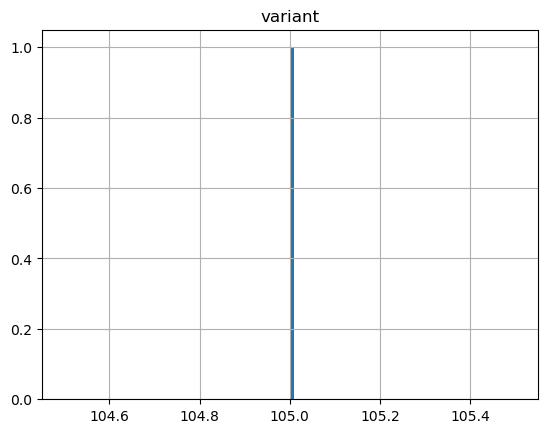

In [22]:
haps_df.groupby(["ENST"]).agg({"variant":"nunique"}).sort_values("variant", ascending=False).hist(bins=100)

## WT variant attribution analysis

Identify the WT variants (observed naturally occurring  in the  biobank cohort). 
Then find how frequency those variants are (inferred by extracting them from the haplotype names after expanding the data from the unique haplotype --> individual level).

Using side-by-side heatmaps we can find superpopulation x WT variant clusters that are frequent in a given superpopulation and/or high mean VEP (across all injected variants). 

In this way, we can identify (superpopulation-specific) WT variants that confer sensitivity to ClinVar variants in general.  

We could also recompute this plot to show only average VEP for a specific ClinVar variant of interest to see which WT variants confer sensitivity to it.

Getting haplotype frequencies:   0%|          | 0/1 [00:00<?, ?it/s]

Using cohorts: {'1000GENOMES:phase_3'}
Using 32 populations
Adding haplotype frequencies per population
Adding top superpopulation

Number of variants specific to each population:
specific_superpopulation
1000GENOMES:phase_3:AFR    33
1000GENOMES:phase_3:SAS    17
1000GENOMES:phase_3:EAS    13
1000GENOMES:phase_3:AMR    13
1000GENOMES:phase_3:EUR    12
Name: count, dtype: int64

Percentage of population-specific haplotypes: 80.73%


/home/schilder/projects/VEP_protein/src/vep_analysis.py:2638: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  var_freqs_agg = var_freqs_agg.fillna(fillna)


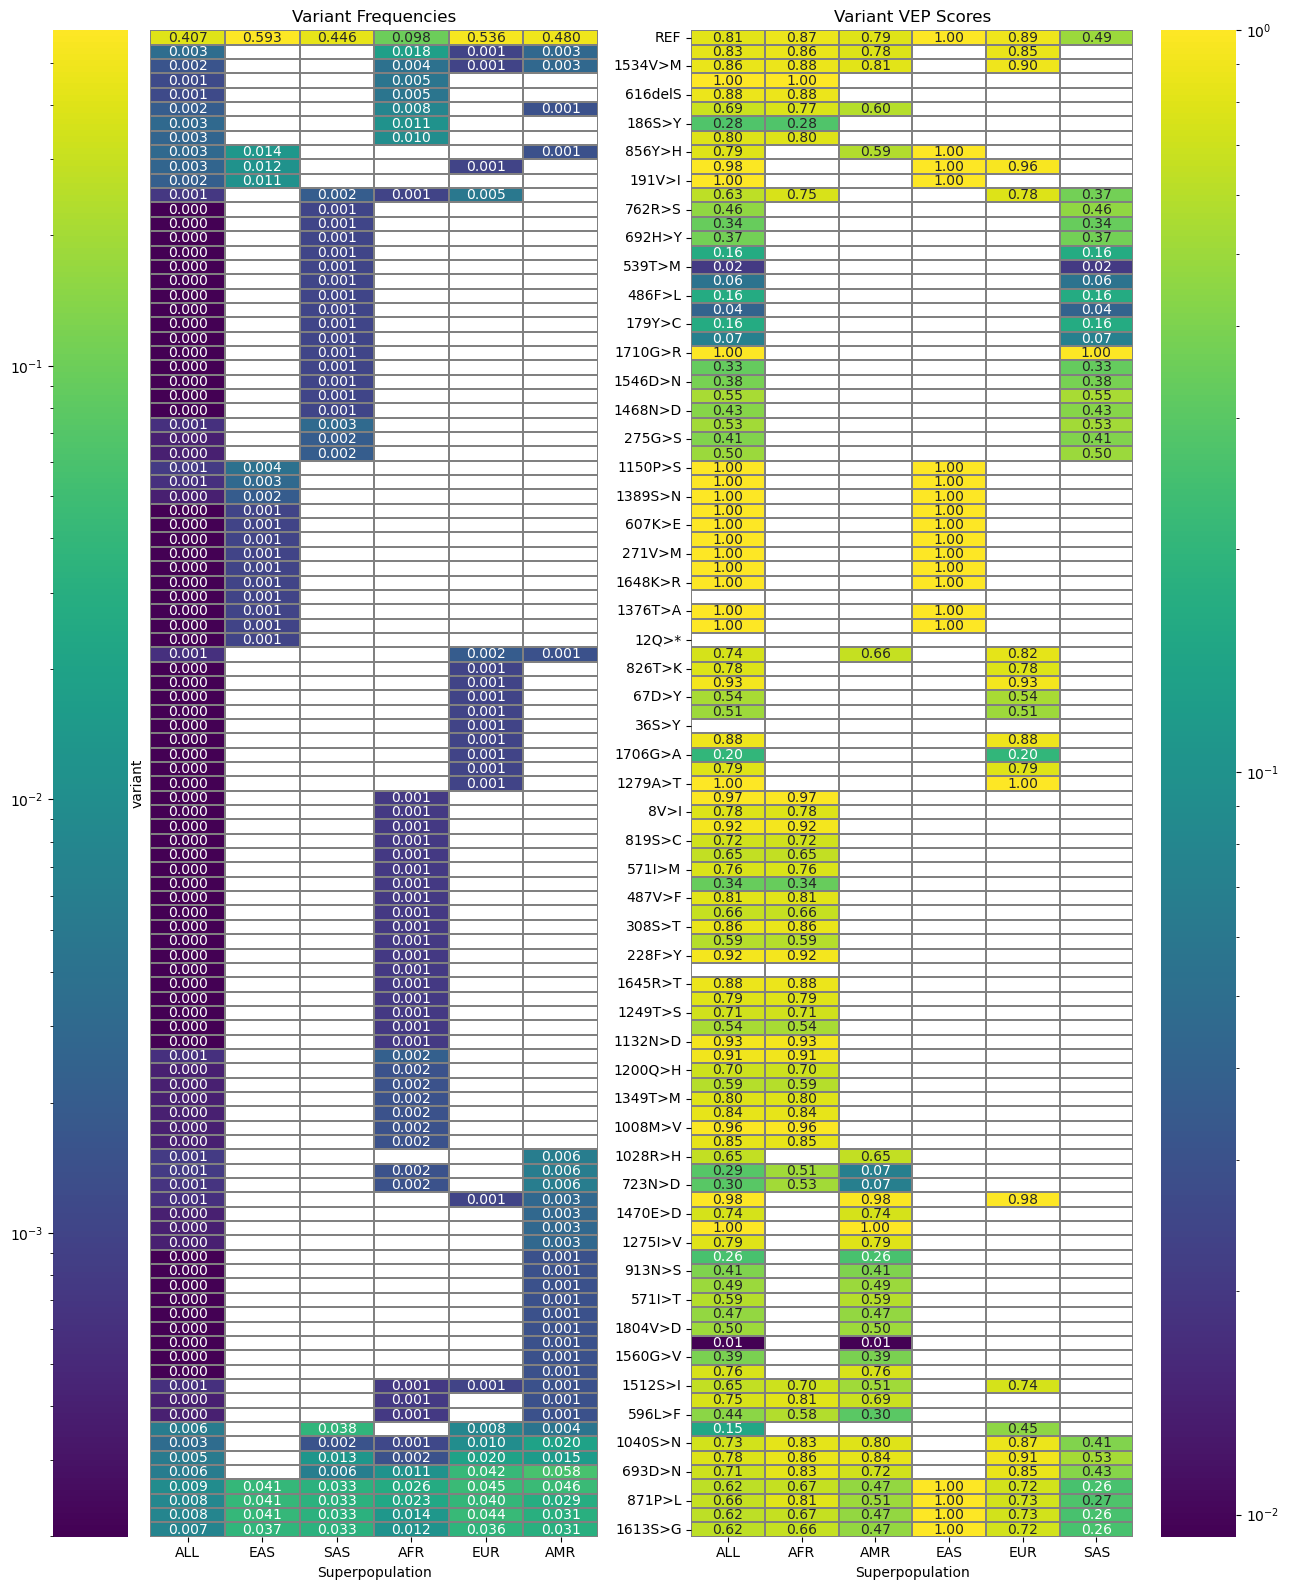

In [23]:
vep_prot, var_vep_agg, var_freqs_agg, fig = va.get_wt_variant_vep_scores(vep_df=vep_df, 
                                                                        haps_df=haps_df,
                                                                        haplotypes=haplotypes, 
                                                                        haps_to_samples=haps_to_samples
                                                                        )

### Dotplot

Same information as the dual heatmaps above, but condense into a single dotplot where the size is the variant frequency and the color is the mean VEP score.

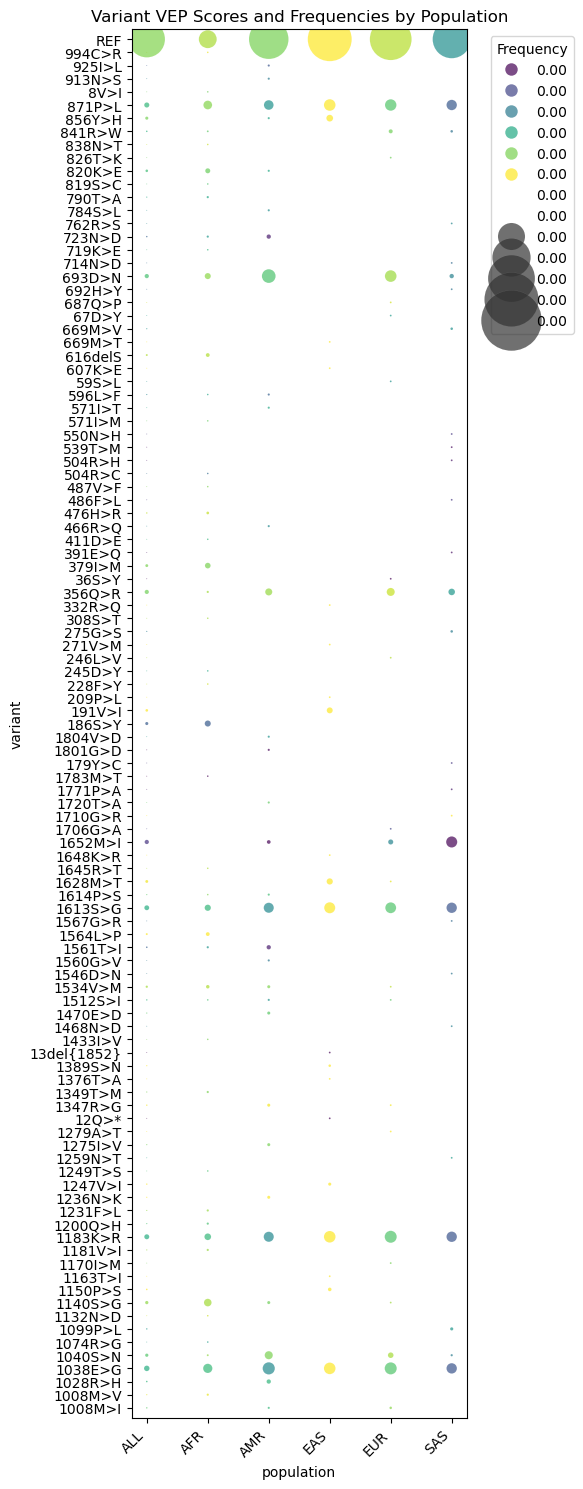

In [24]:
va.plot_wt_variant_vep_scores_dotplot(var_vep_agg, var_freqs_agg)

## Clinical variant x Individual heatmap

(2284104, 78)


/home/schilder/.conda/envs/esm2/lib/python3.12/site-packages/seaborn/matrix.py:560: UserWarning: Clustering large matrix with scipy. Installing `fastcluster` may give better performance.
  warnings.warn(msg)
/home/schilder/.conda/envs/esm2/lib/python3.12/site-packages/seaborn/matrix.py:560: UserWarning: Clustering large matrix with scipy. Installing `fastcluster` may give better performance.
  warnings.warn(msg)


Number of col clusters: 73


/home/schilder/.conda/envs/esm2/lib/python3.12/site-packages/seaborn/matrix.py:560: UserWarning: Clustering large matrix with scipy. Installing `fastcluster` may give better performance.
  warnings.warn(msg)
/home/schilder/.conda/envs/esm2/lib/python3.12/site-packages/seaborn/matrix.py:560: UserWarning: Clustering large matrix with scipy. Installing `fastcluster` may give better performance.
  warnings.warn(msg)


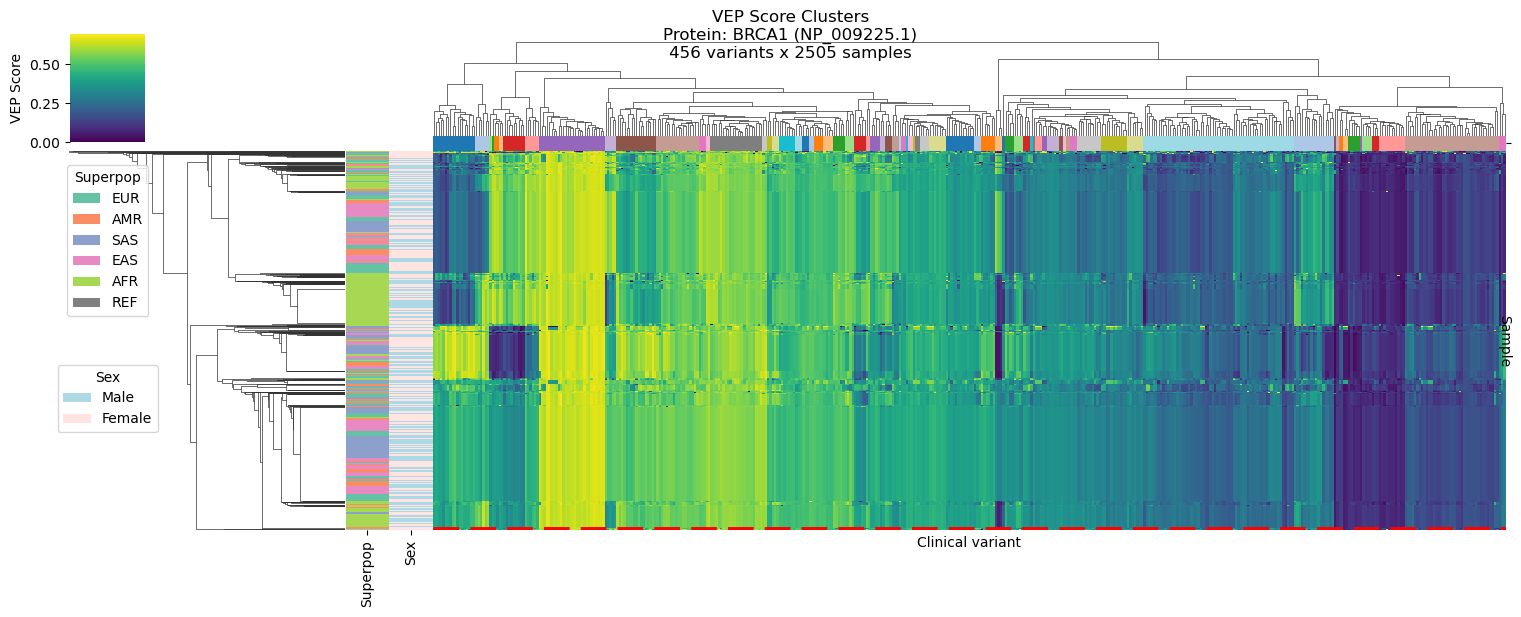

In [25]:
g1, variant_to_cluster = va.sample_by_mutant_clustermap(vep_df, 
                                                        haps_to_samples, 
                                                        figsize=(15,6),
                                                        t=1.15)

## Clinica variant x WT variant sensitization heatmap

Compare mean VEP across WT variants for each injected ClinVar variant.

Adding positions to WT variants
Adding positions to clinical variants
Sorting clinical variants by WT variant positions
Creating color palettes
Inverting scale
Normalizing columns
Creating column colors
Reindexing column colors
Creating row colors
Reindexing row colors
Dropping position column from column colors
Dropping position column from row colors
Creating mask
Creating clustermap


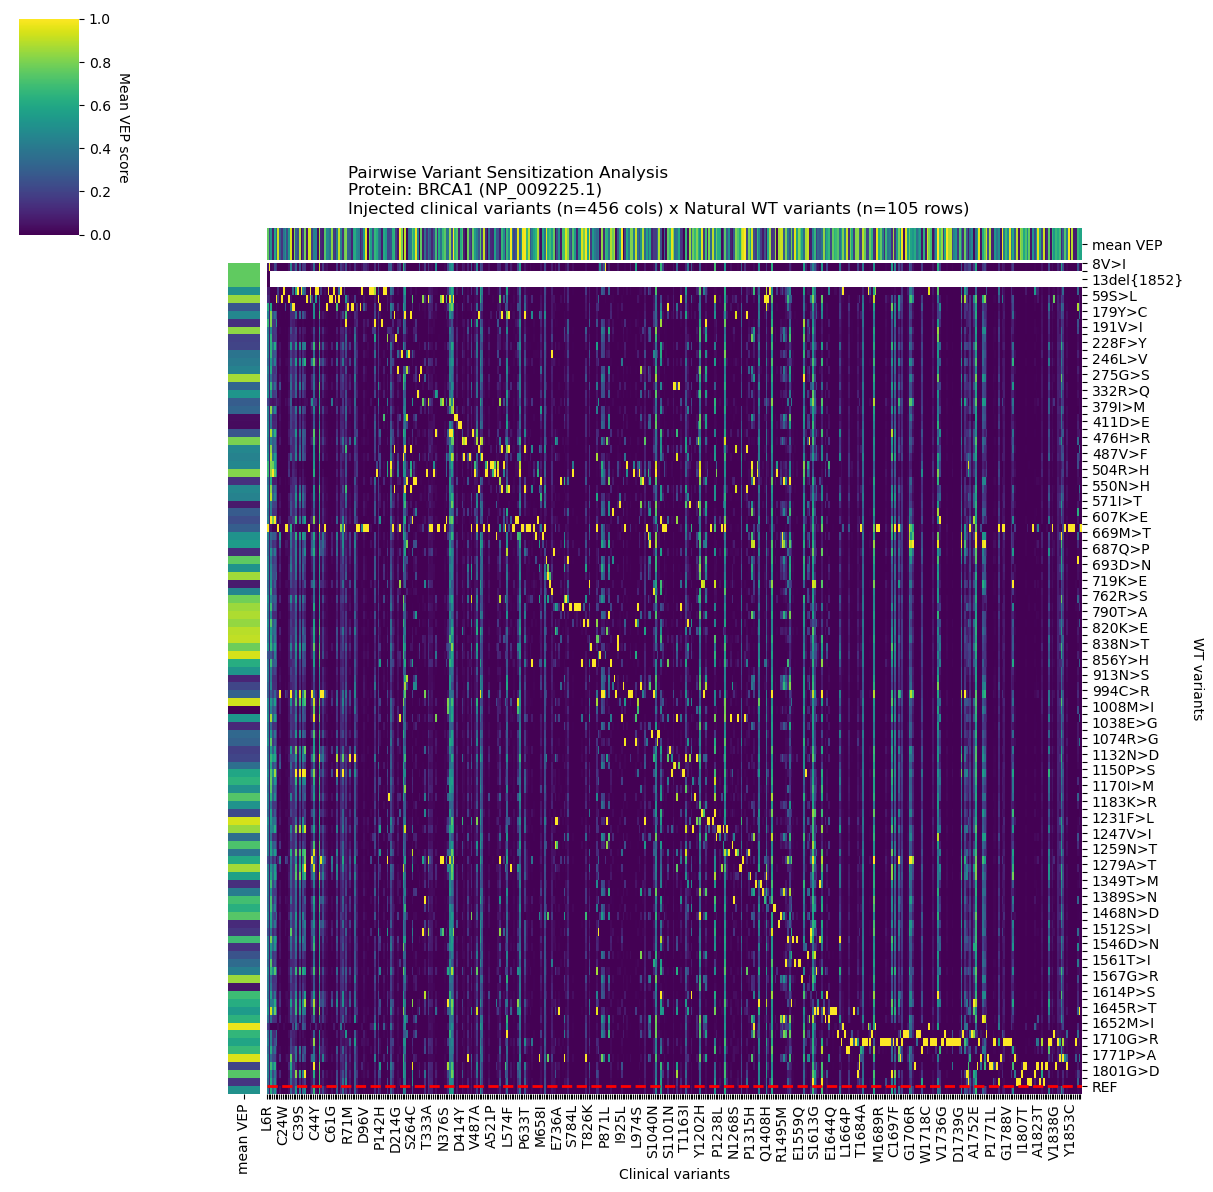

In [26]:
g0, clinvar_vs_wt, row_colors, col_colors = va.pairwise_variant_sensitization_clustermap(
                                          vep_prot=vep_prot, 
                                            figsize=(12,12),
                                            row_cluster=False,
                                            col_cluster=False,
                                              normalize_procedure=["cols"],
                                             title_y=1.05,
                                        #    show_position_per_col=True ,
                                        #     show_position_per_row=True,
                                             pow=10,
                                             ) 

## 2D protein structure

### Import from PDB

The Protein Data Bank (PDB) utilizes two primary file formats for storing and exchanging protein structure information: the legacy PDB format and the more modern CIF (Crystallographic Information Framework) format, also known as PDBx/mmCIF. The CIF format is derived from the STAR format and has been adopted as the standard for deposition since 2014 due to limitations in the original PDB format. 

Here's a comparison of the key features of each format:
1. PDB Format:
Fixed-width format: Data fields are allocated a predetermined number of characters, which can be limiting for large protein complexes exceeding the assigned space.
Legacy format: While widely used due to its long history, the fixed-width format poses limitations, especially with larger protein complexes, and is being phased out.
Structure: Each line, or record, begins with a record name (e.g., "ATOM," "HETATM"), followed by data fields arranged in specific columns. 

2. CIF (PDBx/mmCIF) Format:
Expandable format: The CIF format uses a label-value structure, where data is explicitly named and separated by spaces, allowing for unlimited data content without encountering size restrictions.
Data blocks: CIF files are constructed by concatenating data blocks, each containing label and data columns.
PDB Standard: The CIF format has been the standard for PDB deposition since 2014.
Improved data representation: mmCIF enhances the representation of additional information alongside the atomic coordinates, unlike the limited support in the legacy PDB format. 

In summary: 

- PDB files: Older, fixed-width format, useful for smaller protein structures, but less flexible for large complexes. Still widely used for compatibility with older software.
- CIF files (PDBx/mmCIF): Newer, expandable format with no size restrictions, better suited for large macromolecular structures. The standard for new PDB depositions. 
It's important to note that while the CIF format is the preferred standard, many bioinformatics tools and programs continue to support the legacy PDB format. Conversion tools are available to facilitate the transition between formats. 

In [14]:
# structure = cf.import_pdb("https://alphafold.ebi.ac.uk/files/AF-Q8CGX5-F1-model_v4.pdb") 

# # Calculate the contact map
# contact_map = cf.get_contact_map(structure)

# # Plot the contact map
# plt.matshow(contact_map, cmap='binary')
# plt.title("Protein Contact Map")
# plt.xlabel("Residue Index")
# plt.ylabel("Residue Index")
# plt.show() 

### Import from mmCIF

File /home/schilder/.cache/alphafold_db/AF-P38398-F1-model_v4.cif already exists, skipping download.


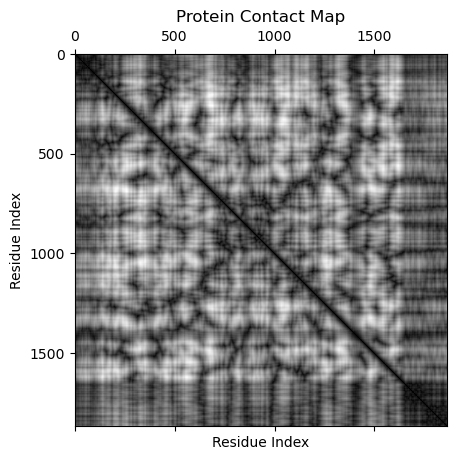

In [53]:
structure = cf.import_mmcif(protein_id = "P38398")

contact_map = cf.get_contact_map(structure, 
                                 max_distance=8.0, 
                                 continuous=True, 
                                 return_distance_map=True )

plt.matshow(contact_map, cmap='binary')
plt.title("Protein Contact Map")
plt.xlabel("Residue Index")
plt.ylabel("Residue Index")
plt.show()

In [54]:
plddt_df = cf.get_plddt(structure)

print(plddt_df["pLDDT"].describe())
print(plddt_df["confidence_category"].value_counts())
plddt_df.head()

Number of residues: 1863
count    1863.000000
mean       41.285357
std        23.417639
min        19.560000
25%        27.935000
50%        30.660000
75%        36.660000
max        97.960000
Name: pLDDT, dtype: float64
confidence_category
very_low     1496
very_high     200
high          125
low            42
Name: count, dtype: int64


,residue,pLDDT,confidence_category,confidence_label,confidence_color
0,1,41.59,very_low,Very low (pLDDT < 50),#FF7D45
1,2,45.81,very_low,Very low (pLDDT < 50),#FF7D45
2,3,48.11,very_low,Very low (pLDDT < 50),#FF7D45
3,4,63.99,low,Low (70 > pLDDT > 50),#FFDB13
4,5,61.73,low,Low (70 > pLDDT > 50),#FFDB13


<Figure size 1000x1000 with 0 Axes>

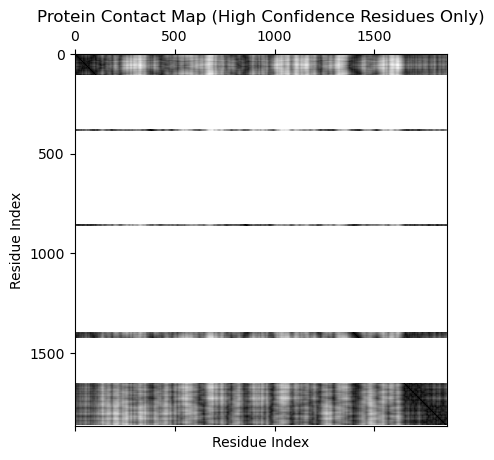

In [14]:
# contact_map
plddt_high = plddt_df.loc[plddt_df["pLDDT"] > 50]
# Filter contact map to only include high confidence residues
contact_map_high_conf = contact_map.copy()
contact_map_high_conf[~plddt_df["residue"].isin(plddt_high["residue"])] = np.nan

# Plot filtered contact map
plt.figure(figsize=(10,10))
plt.matshow(contact_map_high_conf, cmap='binary')
plt.title("Protein Contact Map (High Confidence Residues Only)")
plt.xlabel("Residue Index")
plt.ylabel("Residue Index")
plt.show()


In [15]:
vep_prot = utils.variants_to_positions(vep_prot)
vep_prot.head()

,haplotype,protein,protein_sequence,mutant,mutated_sequence,DMS_bin_score,VEP,scoring_strategy,is_ref,model_location,variant_set,ENSP,ENST,mutant_in_haplotype,#CHROM,POS,ID,REF,ALT,QUAL,FILTER,#Uploaded_variation,Location,Allele,Gene,Feature,Feature_type,Consequence,cDNA_position,CDS_position,Protein_position,Amino_acids,Codons,Existing_variation,IMPACT,DISTANCE,STRAND,FLAGS,REFSEQ_MATCH,REFSEQ_OFFSET,GIVEN_REF,USED_REF,BAM_EDIT,HGVSc,HGVSp,HGVS_OFFSET,AF_ESP,AF_EXAC,ALLELEID,CLNDISDB,CLNDN,CLNHGVS,CLNREVSTAT,CLNSIG,CLNSIGCONF,CLNVC,CLNVCSO,GENEINFO,MC,ORIGIN,RS,AF_TGP,CLNVI,CLNDISDBINCL,CLNDNINCL,CLNSIGINCL,EVH_epistatic,EVH_independent,ESM1V_ensemble_mean,Tranception,model_count,clinsig,variant,variant_VEP_mean,variant_VEP_std,variant_position
10485,ENSP00000350283:1710G>R,NP_009225.1,MDLSALRVEEVQNVINAMQKILECPICLELIKEPVSTKCDHIFCKF...,M18K,MDLSALRVEEVQNVINAKQKILECPICLELIKEPVSTKCDHIFCKF...,Pathogenic,-9.554015,masked-marginals,False,esm2_t33_650M_UR50D,clinical_ProteinGym_substitutions,ENSP00000350283,ENST00000357654,False,17,43124044,55559,A,T,.,PASS,55559,17:43124044,T,672,NM_007294.4,Transcript,missense_variant,166,53,18,M/K,aTg/aAg,-,MODERATE,-,-1,-,-,-,A,A,-,NM_007294.4:c.53T>A,NP_009225.1:p.Met18Lys,-,NaN,NaN,70226,"MONDO:MONDO:0011450,MedGen:C2676676,OMIM:60437...","Breast-ovarian_cancer,_familial,_susceptibilit...",NC_000017.11:g.43124044A>T,"criteria_provided,_multiple_submitters,_no_con...",Likely_pathogenic,NaN,single_nucleotide_variant,SO:0001483,BRCA1:672,"SO:0001583|missense_variant,SO:0001619|non-cod...",1,80356929,NaN,ClinGen:CA003549,NaN,NaN,NaN,NaN,NaN,-3.694999,NaN,6,likely_path,1710G>R,-3.315499,4.437071,1710.0
10453,ENSP00000350283:1710G>R,NP_009225.1,MDLSALRVEEVQNVINAMQKILECPICLELIKEPVSTKCDHIFCKF...,C47F,MDLSALRVEEVQNVINAMQKILECPICLELIKEPVSTKCDHIFCKF...,Pathogenic,-9.820170,masked-marginals,False,esm2_t33_650M_UR50D,clinical_ProteinGym_substitutions,ENSP00000350283,ENST00000357654,False,17,43106528,54247,C,A,.,PASS,54247,17:43106528,A,672,NM_007294.4,Transcript,missense_variant,253,140,47,C/F,tGc/tTc,-,MODERATE,-,-1,-,-,-,C,C,-,NM_007294.4:c.140G>T,NP_009225.1:p.Cys47Phe,-,NaN,NaN,68914,"MONDO:MONDO:0015356,MeSH:D009386,MedGen:C00276...",Hereditary_cancer-predisposing_syndrome|Breast...,NC_000017.11:g.43106528C>A,"criteria_provided,_multiple_submitters,_no_con...",Pathogenic/Likely_pathogenic,NaN,single_nucleotide_variant,SO:0001483,BRCA1:672,"SO:0001583|missense_variant,SO:0001623|5_prime...",1,80357150,NaN,ClinGen:CA000952,NaN,NaN,NaN,NaN,NaN,-9.459467,NaN,6,likely_path,1710G>R,-3.315499,4.437071,1710.0
10484,ENSP00000350283:1710G>R,NP_009225.1,MDLSALRVEEVQNVINAMQKILECPICLELIKEPVSTKCDHIFCKF...,M18T,MDLSALRVEEVQNVINATQKILECPICLELIKEPVSTKCDHIFCKF...,Pathogenic,-5.401980,masked-marginals,False,esm2_t33_650M_UR50D,clinical_ProteinGym_substitutions,ENSP00000350283,ENST00000357654,False,17,43124044,37664,A,G,.,PASS,37664,17:43124044,G,672,NM_007294.4,Transcript,missense_variant,166,53,18,M/T,aTg/aCg,-,MODERATE,-,-1,-,-,-,A,A,-,NM_007294.4:c.53T>C,NP_009225.1:p.Met18Thr,-,NaN,NaN,46220,"MONDO:MONDO:0015356,MeSH:D009386,MedGen:C00276...",Hereditary_cancer-predisposing_syndrome|not_pr...,NC_000017.11:g.43124044A>G,reviewed_by_expert_panel,Pathogenic,NaN,single_nucleotide_variant,SO:0001483,BRCA1:672,"SO:0001583|missense_variant,SO:0001619|non-cod...",1,80356929,NaN,ClinGen:CA003550|UniProtKB:P38398#VAR_063899,NaN,NaN,NaN,NaN,NaN,-0.984293,NaN,6,path,1710G>R,-3.315499,4.437071,1710.0
10483,ENSP00000350283:1710G>R,NP_009225.1,MDLSALRVEEVQNVINAMQKILECPICLELIKEPVSTKCDHIFCKF...,M18R,MDLSALRVEEVQNVINARQKILECPICLELIKEPVSTKCDHIFCKF...,Pathogenic,-9.810849,masked-marginals,False,esm2_t33_650M_UR50D,clinical_ProteinGym_substitutions,ENSP00000350283,ENST00000357654,False,17,43124044,531241,A,C,.,PASS,531241,17:43124044,C,672,NM_007294.4,Transcript,missense_variant,166,53,18,M/R,aTg/aGg,-,MODERATE,-,-1,-,-,-,A,A,-,NM_007294.4:c.53T>G,NP_009225.1:p.Met18Arg,-,NaN,NaN,531135,"MONDO:MONDO:0003582,MeSH:D061325,MedGen:C06777..."

104
(133722, 12)


/home/schilder/projects/VEP_protein/src/utils.py:1422: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df.loc[:, position_col] = df[variant_col].map(positions)
/home/schilder/projects/VEP_protein/src/utils.py:1422: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df.loc[:, position_col] = df[variant_col].map(positions)


104


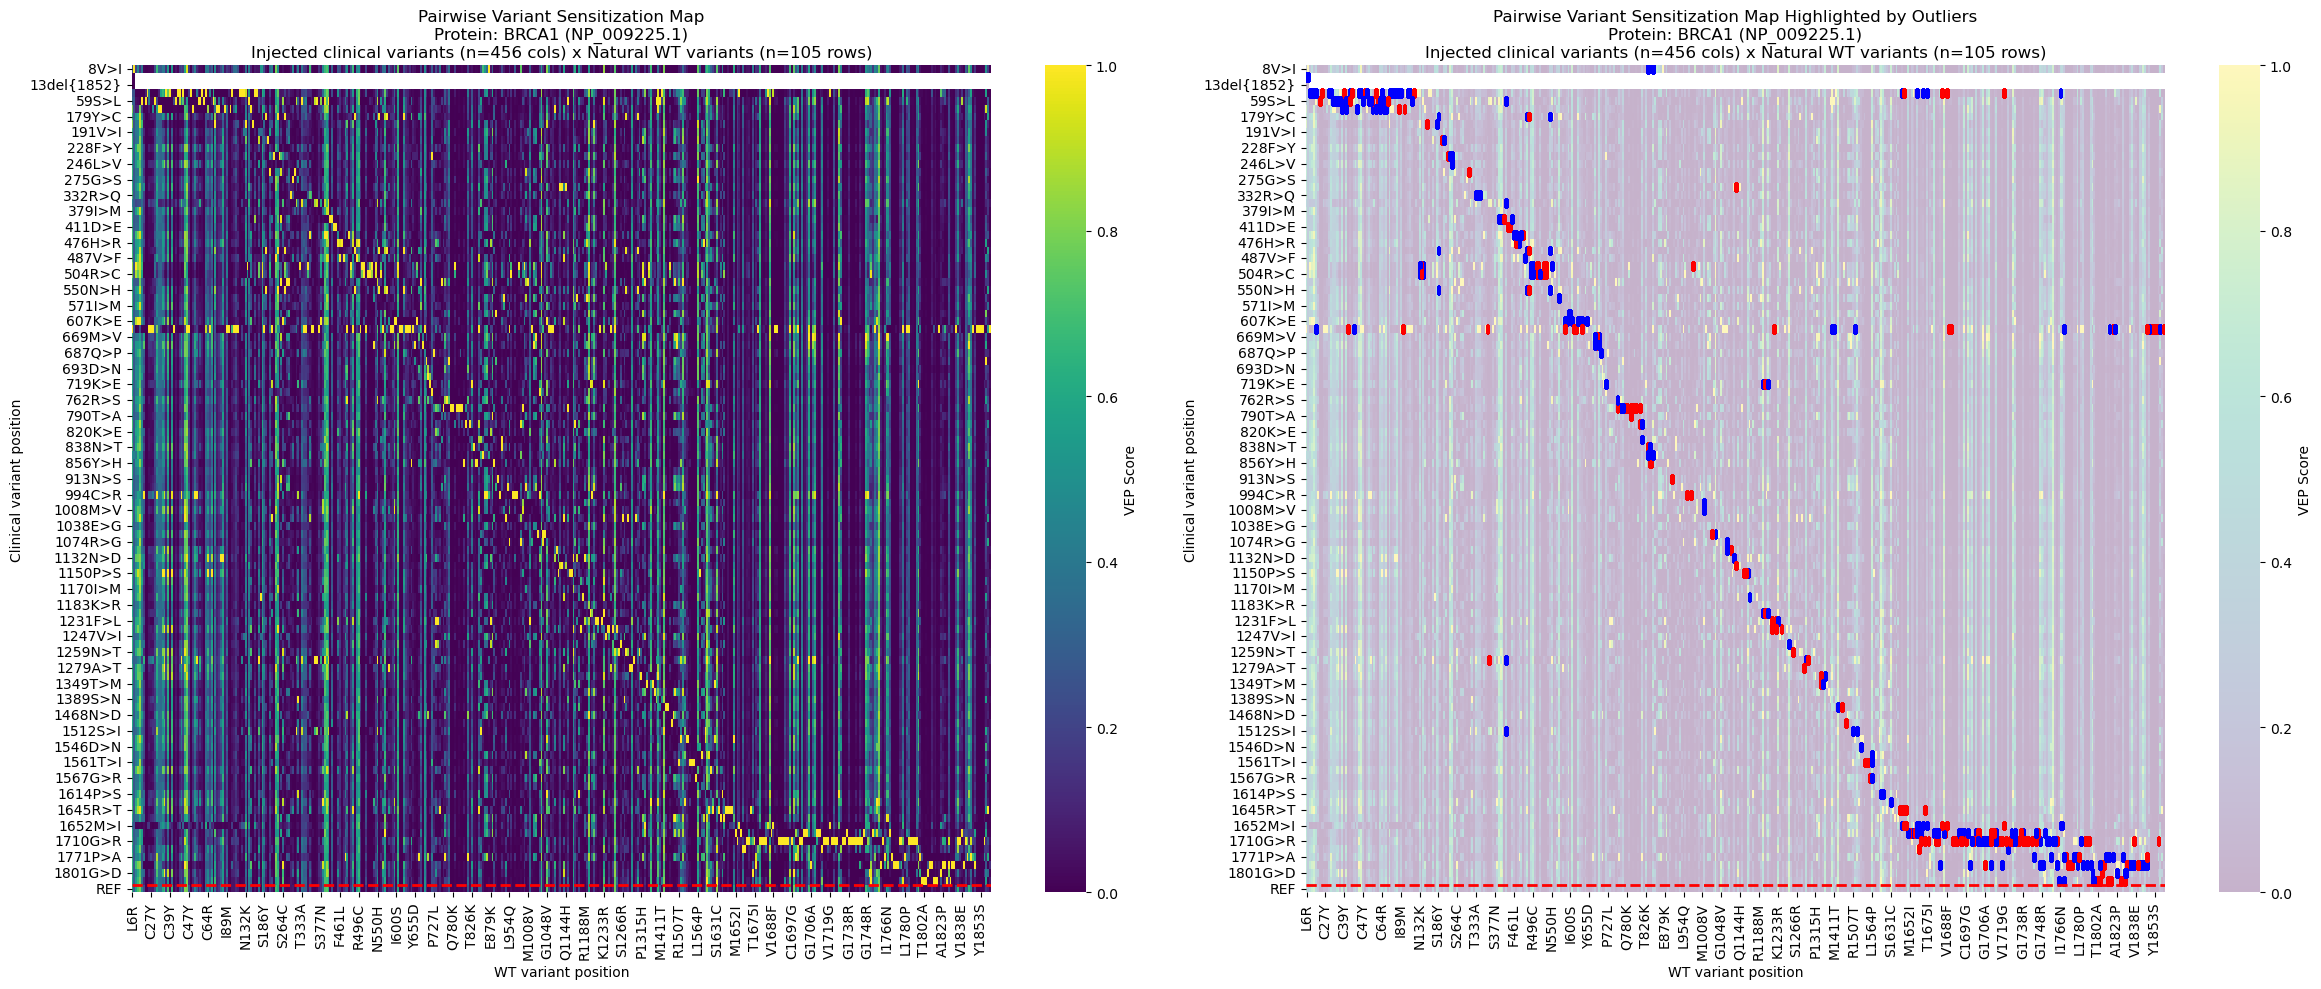

In [ ]:
# Create figure with two subplots side by side
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(24,10))

# Get outlier analysis and display results
outlier_df = va.identify_outliers(clinvar_vs_wt)

Xs = clinvar_vs_wt**5

ref_linewidth=2
# First heatmap - original
sns.heatmap(Xs, 
            cmap='viridis', 
            cbar_kws={'label': 'VEP Score'}, 
            alpha=1, ax=ax1)
ax1.set_xlabel("WT variant position")
ax1.set_ylabel("Clinical variant position")
ax1.set_title(f"Pairwise Variant Sensitization Map\nProtein: {vep_prot["GENEINFO"].unique()[0].split(':')[0]} ({vep_prot['protein'].unique()[0]})\nInjected clinical variants (n={clinvar_vs_wt.shape[1]} cols) x Natural WT variants (n={clinvar_vs_wt.shape[0]} rows)",
                        )
ax1.tick_params(axis='x', rotation=90)
if ref_linewidth is not None:
    ref_idx = np.where(np.array([x for x in clinvar_vs_wt.index]) == 'REF')[0][0]
    print(ref_idx)
    ax1.axhline(y=ref_idx, color='red', linestyle='--', alpha=1, linewidth=ref_linewidth)

 
# Filter to most sig results
outlier_sig = outlier_df[
        (outlier_df['significant']) &  # Must be signifiacant after FDR correction
        (abs(outlier_df['z_score']) > 4.5) &  # Must have very extreme z-scores
        (outlier_df['p_adjusted'] < 0.001)  # Must have very small adjusted p-values
    ].copy()

if "clinsig" in outlier_sig.columns:
   outlier_sig['is_pathogenic'] = outlier_sig['clinsig'].isin(["path", "likely path"]) 

# Add sequence positions to the outlier dataframe
outlier_sig = utils.variants_to_positions(outlier_sig, 
                                          variant_col="wt_variant", 
                                          position_col="wt_position")
outlier_sig = utils.variants_to_positions(outlier_sig, 
                                          variant_col="clinical_variant", 
                                          position_col="clinical_position")

# Rmove outliers with the same sequence position
# These are not necessarily the same exact variant, but they are the same sequence position so you can't actually have both at the same
outlier_sig = outlier_sig.loc[outlier_sig["wt_position"] != outlier_sig["clinical_position"]]

# Remove large deletions
outlier_sig = outlier_sig.loc[~(outlier_sig["wt_variant"].str.contains("del{") | outlier_sig["wt_variant"].str.contains("del{"))]
outlier_sig = outlier_sig.merge(vep_prot[["mutant", "clinsig"]], 
                                left_on="clinical_variant", 
                                right_on="mutant", how="left")

print(outlier_sig.shape)

# Second heatmap - with highlighted outliers
sns.heatmap(Xs, cmap='viridis', cbar_kws={'label': 'VEP Score'}, 
            alpha=0.3, ax=ax2)
 
va.add_rectangles(X=Xs, 
                  xy_pairs=outlier_sig, 
                  x_col="wt_variant",
                  y_col="clinical_variant",
                  color_col="outlier_type",
                  cmap={"high": "red", "low": "blue"} )

ax2.set_xlabel("WT variant position")
ax2.set_ylabel("Clinical variant position")
ax2.set_title(f"Pairwise Variant Sensitization Map Highlighted by Outliers\nProtein: {vep_prot["GENEINFO"].unique()[0].split(':')[0]} ({vep_prot['protein'].unique()[0]})\nInjected clinical variants (n={clinvar_vs_wt.shape[1]} cols) x Natural WT variants (n={clinvar_vs_wt.shape[0]} rows)",)
ax2.tick_params(axis='x', rotation=90)
if ref_linewidth is not None:
    ref_idx = np.where(np.array([x for x in clinvar_vs_wt.index]) == 'REF')[0][0]
    print(ref_idx)
    ax2.axhline(y=ref_idx, color='red', linestyle='--', alpha=1, linewidth=ref_linewidth) 

plt.tight_layout() 

Normalizing columns
Expanding x-axis by 3
Expanding y-axis by 3


/home/schilder/projects/VEP_protein/src/colabfold.py:249: RuntimeWarning: All-NaN slice encountered
  return agg_func(


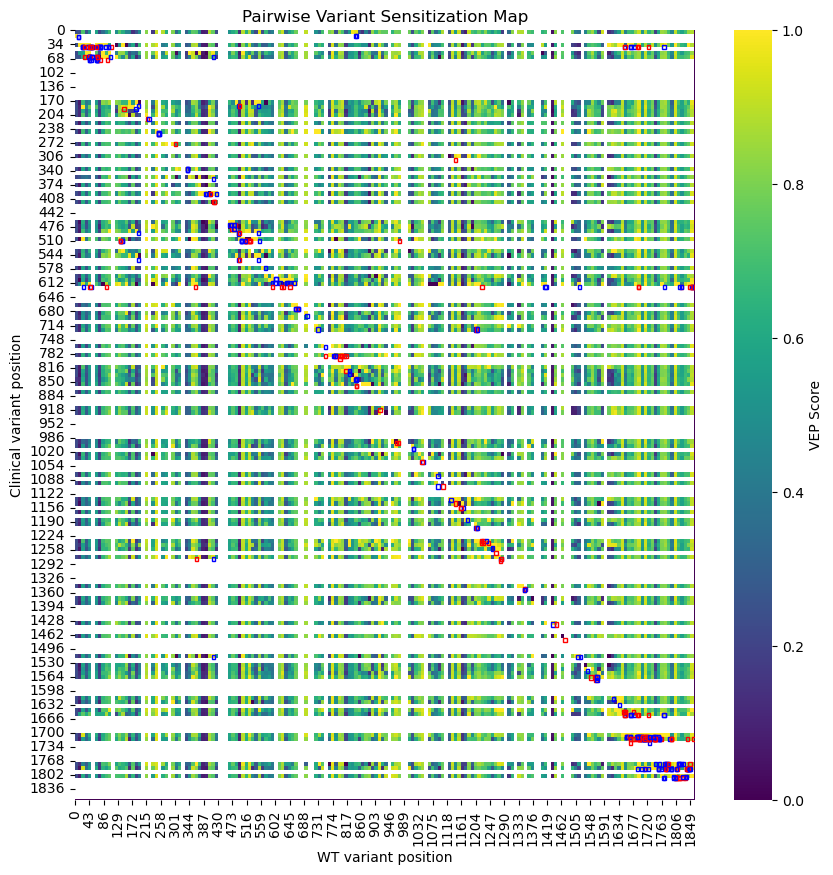

In [34]:
# # Create empty matrix filled with zeros
# matrix_size = 1863  # Total protein length
# vep_matrix = np.zeros((matrix_size, matrix_size))
# # Fill matrix with mean VEP values
# for _, row in vep_prot.loc[vep_prot["variant"] != "REF"].iterrows():
#     # Handle NaN values in variant_position
#     if pd.isna(row['variant_position']):
#         continue
#     else:
#         i = int(row['Protein_position']) - 1  # Convert to 0-based indexing
#         j = int(row['variant_position']) - 1
#         vep_matrix[i, j] = row['VEP']  # Only fill one direction to maintain row=Protein, col=variant

# # Invert the matrix so that higher VEP scores are more red
# vep_matrix = vep_matrix*-1

# # Normalize each row to sum to 1, skipping NAs
# normalize_rows = True
# if normalize_rows:
#     row_sums = np.nansum(vep_matrix, axis=1, keepdims=True)
#     vep_matrix = np.divide(vep_matrix, row_sums, where=(row_sums!=0) & (row_sums!=np.nan))


# # Normalize the whole matrix to a scale from 0 to 1
# # vep_matrix = (vep_matrix - np.nanmin(vep_matrix)) / (np.nanmax(vep_matrix) - np.nanmin(vep_matrix))
# # # Invert the matrix
# # vep_matrix = 1 - vep_matrix

# # Log
# # vep_matrix = vep_matrix**1.05
# # vep_matrix = np.log1p(vep_matrix)


# import scipy.spatial.distance
# corr_axis = None
# if corr_axis == "x":
#     # Calculate cosine similarity along rows
#     vep_matrix = scipy.spatial.distance.cdist(vep_matrix, vep_matrix, metric='cosine')
#     vep_matrix = np.nanmax(vep_matrix) - vep_matrix
# elif corr_axis == "y":
#     # Calculate cosine similarity along columns
#     vep_matrix = scipy.spatial.distance.cdist(vep_matrix.T, vep_matrix.T, metric='cosine')
#     vep_matrix = np.nanmax(vep_matrix) - vep_matrix

 

# # Bin the matrix
# bin_size=20
# vep_matrix_binned = cf.bin_matrix(vep_matrix.copy(), bin_size=bin_size, agg_func=np.nanmax)
# n_bins = vep_matrix_binned.shape[0]
# # Invert the contact matrix
# # vep_matrix = np.log10(vep_matrix + 1e-6)
# # vep_matrix = np.nan_to_num(vep_matrix, nan=0) 


# # Plot the contact matrix
# # plt.figure(figsize=(12, 10))
# plt.imshow(vep_matrix_binned, cmap='jet')
# plt.colorbar().ax.set_ylabel("Mean VEP Score", 
#                                 rotation=270, 
#                                 va="bottom") 

# plt.title('Pairwise Variant Sensitization Map')
# plt.xlabel('WT variant position')
# plt.ylabel('Clinical variant position')

# cf.label_bins(bin_size, n_bins)

# plt.show()

full_length = 1863 


# Add sequence positions to the outlier dataframe
vep_prot = utils.variants_to_positions(vep_prot, 
                                          variant_col="variant", 
                                          position_col="variant_position")
vep_prot = utils.variants_to_positions(vep_prot, 
                                          variant_col="mutant", 
                                          position_col="mutant_position")
Xs = utils.fill_coordinates(vep_prot, full_length=full_length) 
plt.figure(figsize=(10,10))

target_size = 1863
bin_size = 10

Xs = utils.minmax_normalize(Xs, procedure=["cols"])

# Set diagonal to nan
Xs.values[np.diag_indices_from(Xs)] = np.nan

Xs_binned = cf.bin_matrix(Xs, bin_size=bin_size)
Xs_binned = cf.expand_matrix(Xs_binned, target_size=target_size)
sns.heatmap(Xs_binned, cmap='viridis', cbar_kws={'label': 'VEP Score'})
plt.title('Pairwise Variant Sensitization Map')
plt.xlabel('WT variant position')
plt.ylabel('Clinical variant position')


va.add_rectangles(xy_pairs=outlier_sig, 
                  width=10,
                  height=10,
                  xy_pairs_are_idx=True,
                  x_col="wt_position",
                  y_col="clinical_position",
                  color_col="outlier_type",
                  cmap={"high": "red", "low": "blue"} )


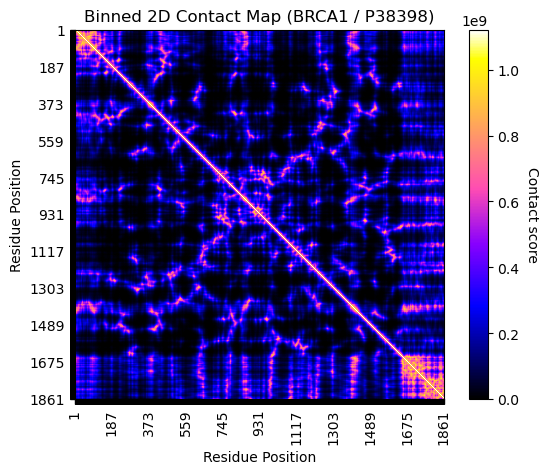

In [55]:
protein_name = "BRCA1"
protein_id = "P38398"

contact_map, contact_map_binned = cf.plot_contact_map(contact_map=contact_map, 
                    title=f"Binned 2D Contact Map ({protein_name} / {protein_id})",  
                    bin_size=1, 
                    log_before_bin=False, 
                    log_after_bin=False, 
                    max_labels=10, 
                    pow=4,
                    cmap="gnuplot2",
                    agg_func=np.nanmax)

Matrix already has target size 1863x1863
(1863, 1863)
Adding rectangles


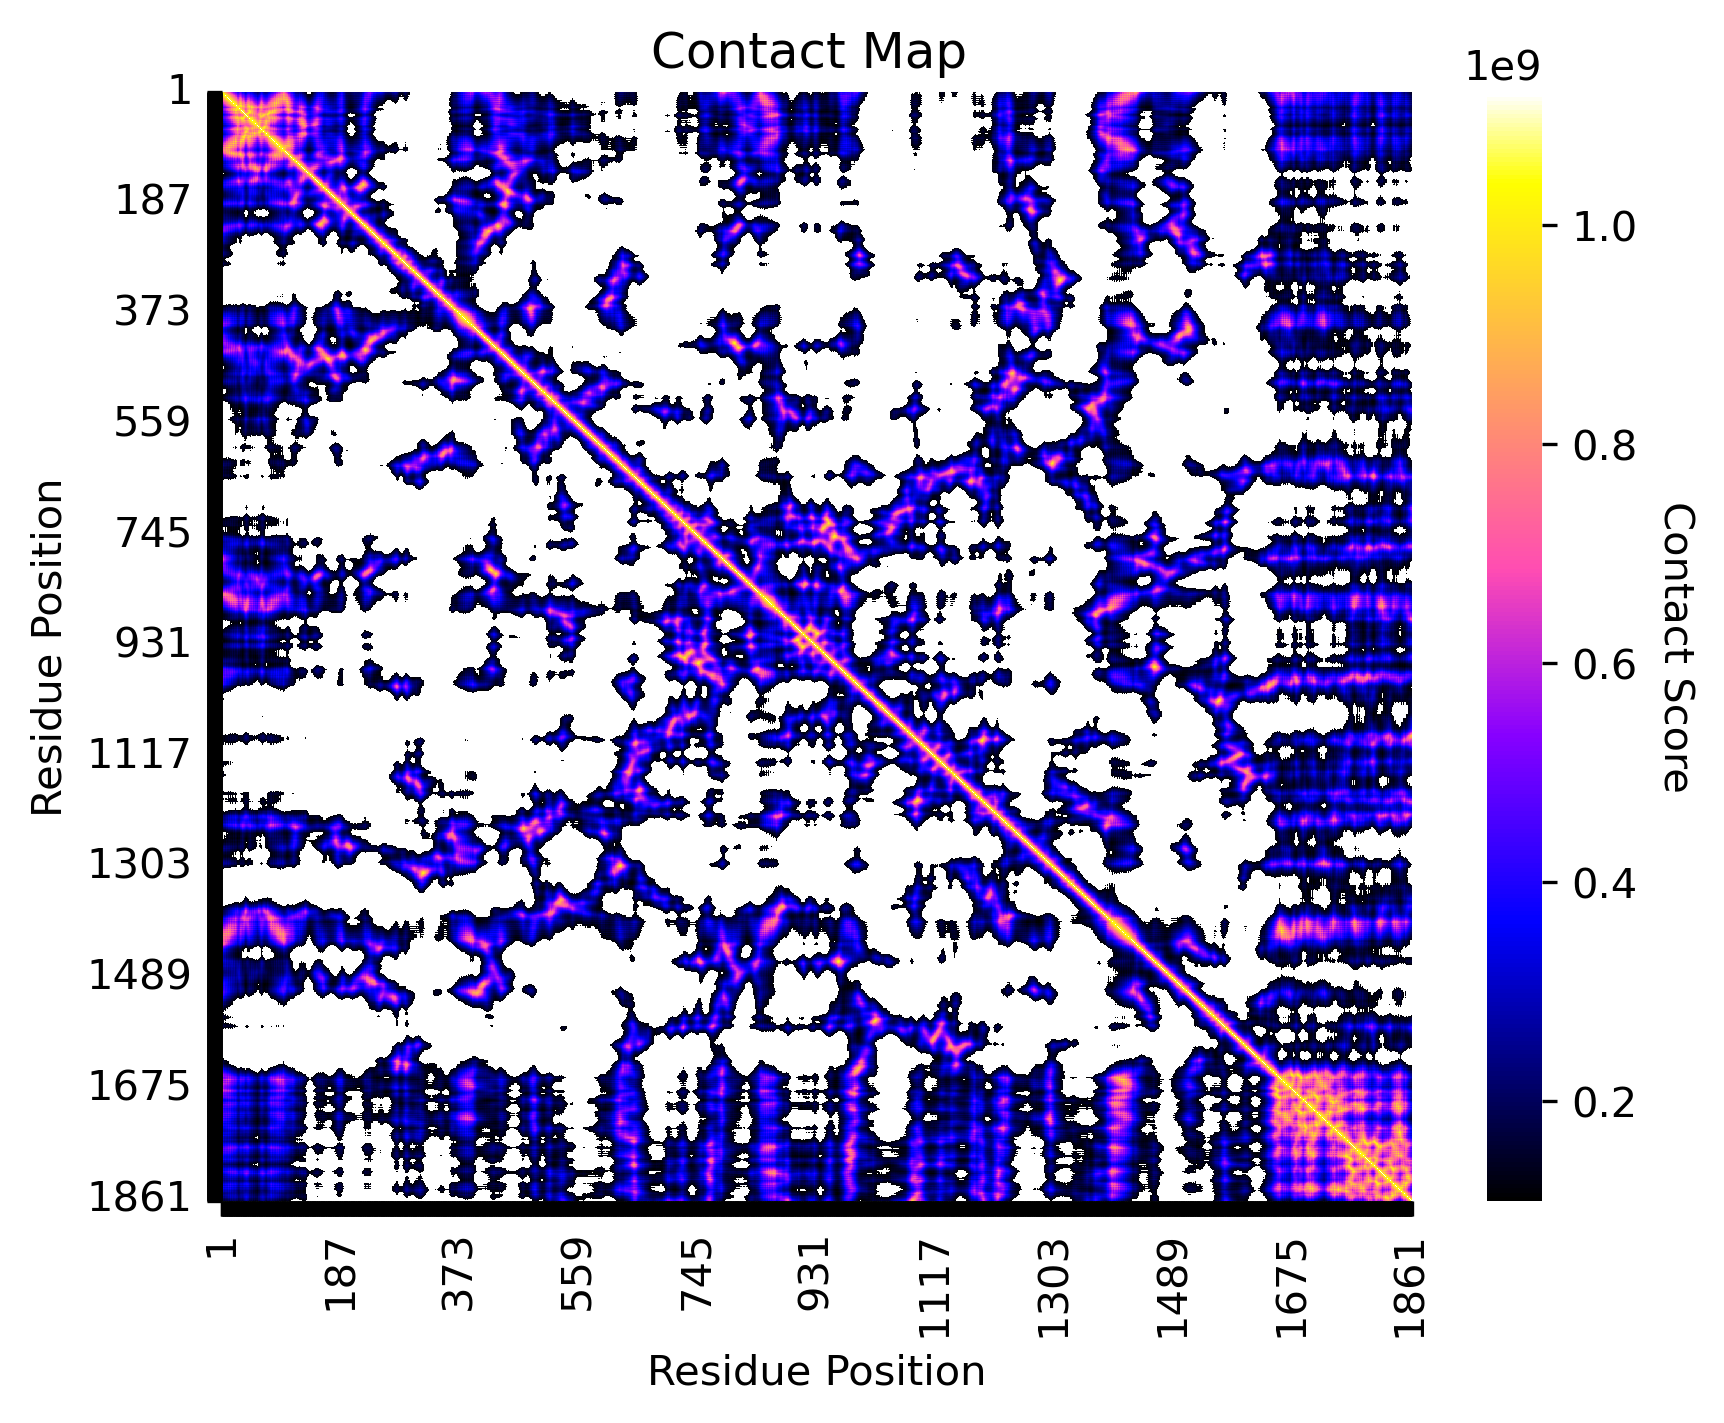

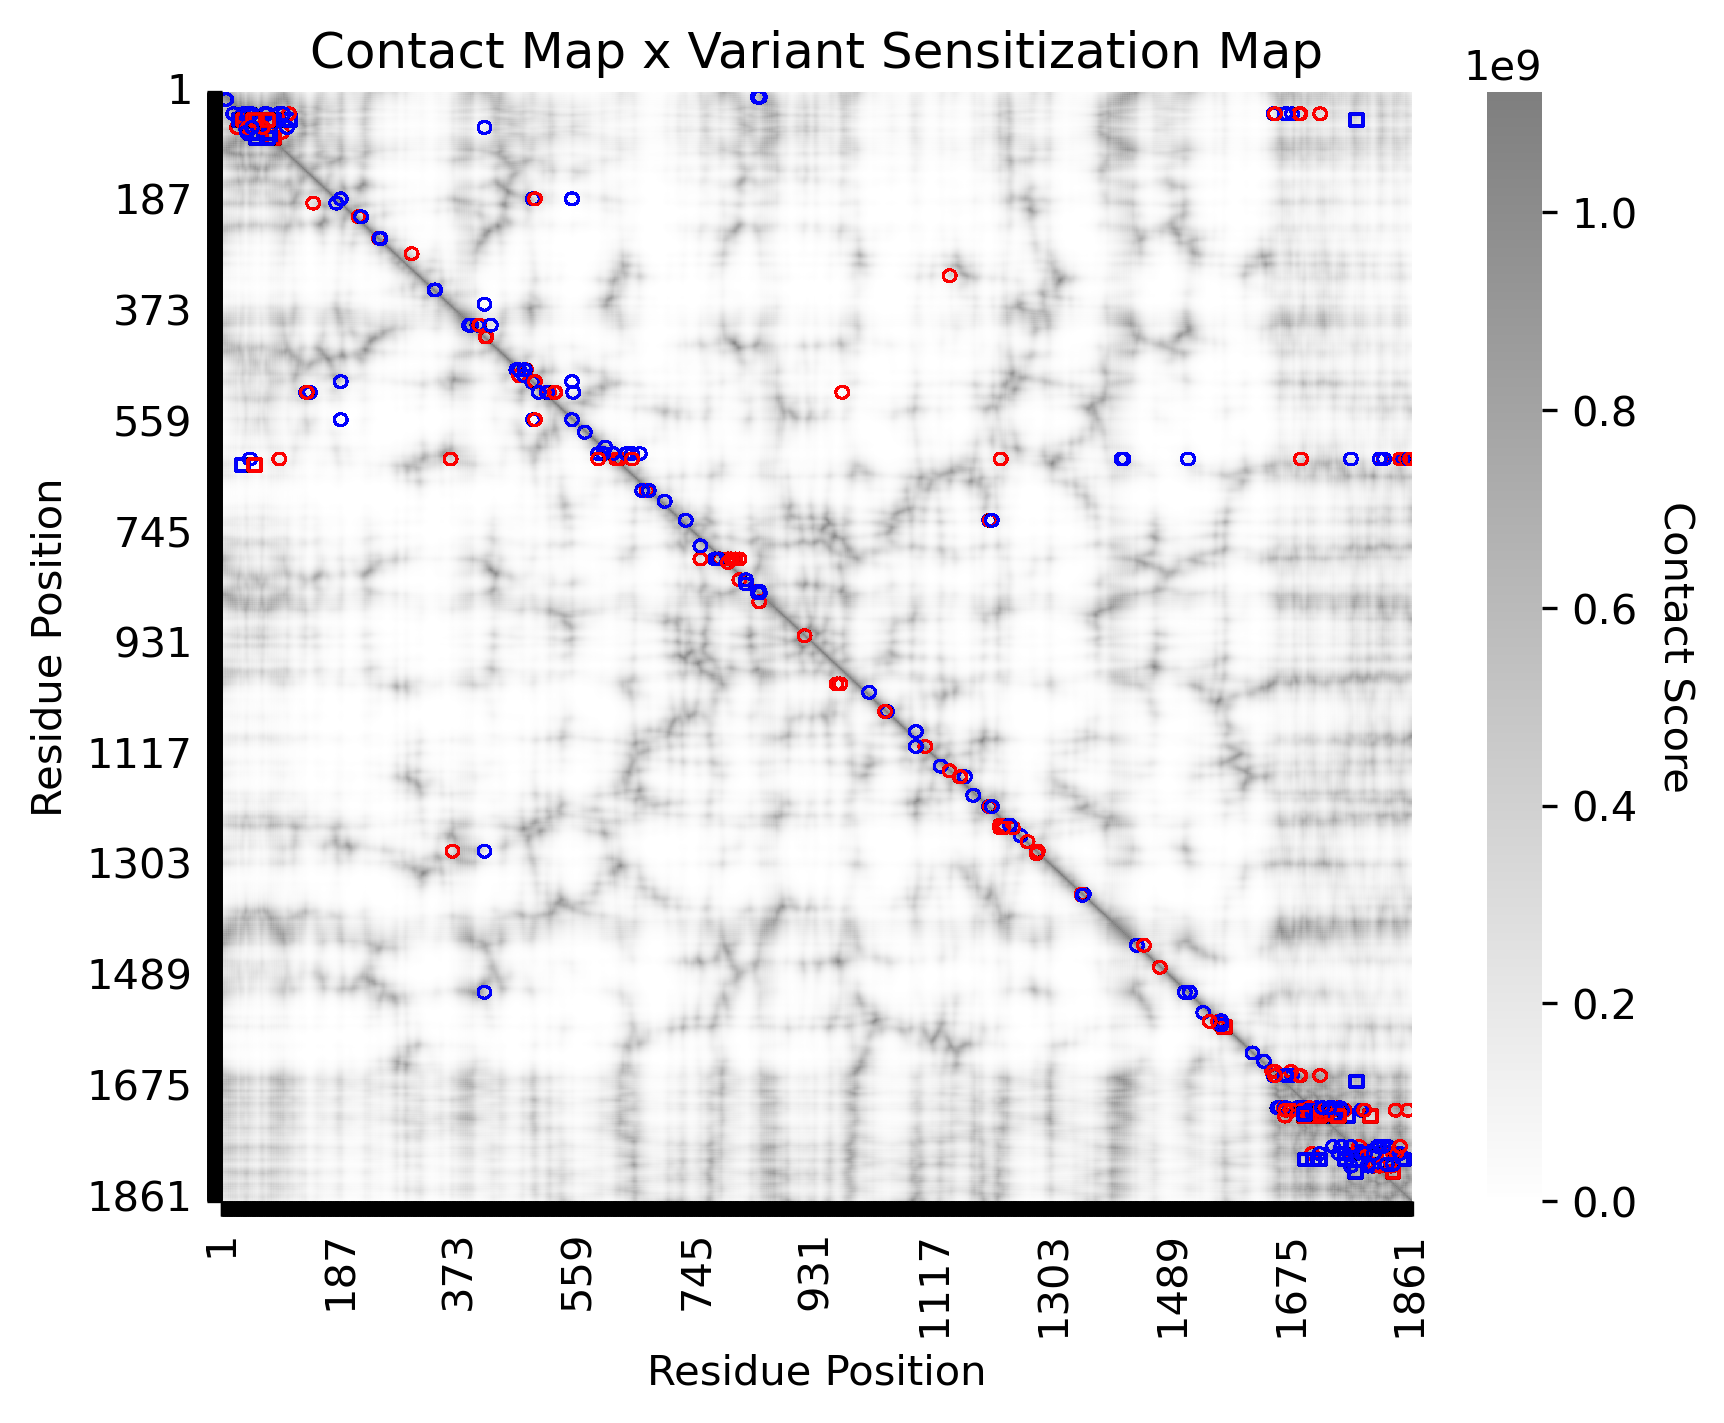

In [77]:
contact_map_unbinned = cf.expand_matrix(contact_map_binned, target_size=1863)
print(contact_map_unbinned.shape)

# Create figure with high DPI for better resolution
add_rect=True
dpi=300
save_fig = False
save_path=f"contact_map_{"sensitization_map" if add_rect else ""}.png"
cmap = "gnuplot2"
if add_rect:
    heatmap_alpha=.5
else:
    heatmap_alpha=1
height_width = 20

mask_color = None

# Calculate threshold for bottom 10% of values
# masking_threshold = 0.1*1e9
masking_threshold = np.percentile(contact_map_unbinned[~np.isnan(contact_map_unbinned)], q=50)
mask = contact_map_unbinned < masking_threshold


def add_plot_labels(g, 
                    bin_size,
                    n_bins,
                    xlabel="Clinical Variant Position", 
                    ylabel="WT Variant Position", 
                    title=None,
                    add_rect=False):
    if title is None:
        title = f"Contact Map {"x Variant Sensitization Map" if add_rect else ""}"
    
    g.collections[0].colorbar.set_label("Contact Score", rotation=270, va="bottom")
    plt.xlabel(xlabel)
    plt.ylabel(ylabel)
    plt.title(title)
    cf.label_bins(bin_size=bin_size, n_bins=n_bins)

def color_mask(g, mask_color = None):
    # Set the color for masked values 
    if mask_color is not None:
        g.collections[0].get_cmap().set_bad(mask_color)



##### PLOT 1 #####
plt.figure(dpi=dpi)

# Plot contact map with rectangles around clusters
g = sns.heatmap(contact_map_unbinned,
                cmap=cmap,
                mask=mask,
                alpha=1) 
add_plot_labels(g, bin_size=1, 
                n_bins=contact_map_unbinned.shape[0], 
                add_rect=False, 
                xlabel="Residue Position", 
                ylabel="Residue Position")
color_mask(g, mask_color=mask_color)


##### PLOT 2 #####
plt.figure(dpi=dpi)
masking_threshold = np.percentile(contact_map_unbinned[~np.isnan(contact_map_unbinned)], q=25)
mask = contact_map_unbinned < masking_threshold
# Plot contact map with rectangles around clusters
g = sns.heatmap(contact_map_unbinned,
                cmap="binary",
                # mask=mask,
                alpha=heatmap_alpha)

# Plot labels
add_plot_labels(g, bin_size=1, 
                n_bins=contact_map_unbinned.shape[0], 
                add_rect=True, 
                xlabel="Residue Position", 
                ylabel="Residue Position")
color_mask(g, mask_color=mask_color)

# Add rectangles around high-confidence sensitization variants
if add_rect:    
    va.add_rectangles(xy_pairs = outlier_sig,#.loc[outlier_sig["clinsig"].isin(["path", ])], 
                    width=height_width,
                    height=height_width,
                    xy_pairs_are_idx=True,
                    fill=False,
                    alpha=0.9,
                    x_col="wt_position",
                    y_col="clinical_position",
                    color_col="outlier_type",
                    shape_col="is_pathogenic",
                    cmap={"high": "red", "low": "blue"} )



# Save figure with high resolution
if save_fig:
    plt.savefig(save_path, dpi=dpi, bbox_inches='tight')
plt.show()

Contact map 90th percentile: 118.12671661376953
VEP matrix 90th percentile: 0.7882186110685288
High contact: 302574
High VEP: 347000
High both: 23295


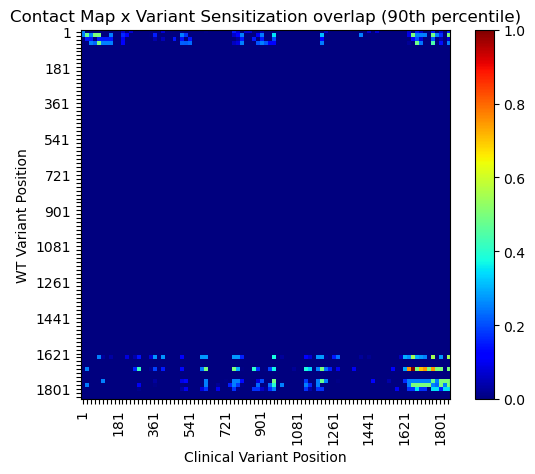

In [36]:
# Calculate 95th percentile for each matrix

method = "linear"

# Set diagonals to nan
# np.fill_diagonal(contact_map, np.nan)
# np.fill_diagonal(vep_matrix, np.nan)


pctl = [90,90]
# Create a copy of contact_map and set diagonal to nan

pctl1 = pctl[0]
# contact_map_no_diag = contact_map.copy()
# np.fill_diagonal(contact_map_no_diag, np.nan)
# contact_map_95th = np.percentile(np.nan_to_num(contact_map_no_diag, nan=np.nanmedian(contact_map_no_diag)), q=pctl1, method=method)
# print(f"Contact map {pctl1}th percentile:", contact_map_95th)

# Filter based on confidence category and ensure alignment with contact map
high_confidence_mask = plddt_df.set_index("residue").reindex(range(contact_map.shape[0]))["confidence_category"].isin(["high", "very_high"]).values 
# Apply mask to matrices
contact_map_no_diag = contact_map.copy()
np.fill_diagonal(contact_map_no_diag, np.nan)
# Set low confidence residues to nan
contact_map_no_diag[~high_confidence_mask] = np.nan
# Find 95th percentile
contact_map_95th = np.percentile(np.nan_to_num(contact_map_no_diag, nan=np.nanmedian(contact_map_no_diag)), q=pctl1, method=method)
print(f"Contact map {pctl1}th percentile:", contact_map_95th)




# Create a copy of vep_matrix and set diagonal to nan
pctl2=pctl[1]
# Xs_no_diag = cf.expand_matrix(Xs_binned, target_size=1863)
# np.fill_diagonal(Xs_no_diag, np.nan)
Xs_no_diag = Xs_binned.copy()
Xs_95th = np.percentile(np.nan_to_num(Xs_no_diag, nan=np.nanmedian(Xs_no_diag)), q=pctl2, method=method)
print(f"VEP matrix {pctl2}th percentile:", Xs_95th)

# Find indices where both matrices exceed their 95th percentile
high_contact = contact_map_no_diag > contact_map_95th
high_vep = Xs_no_diag > Xs_95th
high_both = np.logical_and(high_contact, high_vep)

print(f"High contact: {high_contact.sum()}")
print(f"High VEP: {high_vep.sum()}")
print(f"High both: {high_both.sum()}")



bin_size=20
high_both_binned = cf.bin_matrix(high_both, bin_size=bin_size, agg_func=np.nanmean) 
n_bins = high_both_binned.shape[0]
# high_both_binned = np.log10(high_both_binned+1e-6)

plt.imshow(high_both_binned, cmap='jet')
cf.label_bins(bin_size, n_bins)
plt.colorbar() 
plt.xlabel("Clinical Variant Position")
plt.ylabel("WT Variant Position")
plt.title(f"Contact Map x Variant Sensitization overlap ({pctl1}th percentile)")
plt.show()





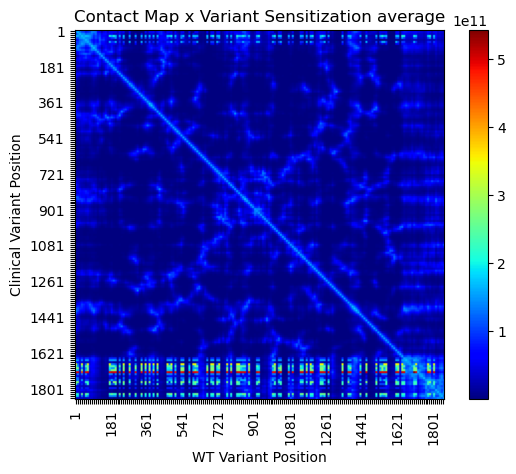

Where both matrices exceed 95th percentile: 24311


In [168]:
# np.fill_diagonal(high_both, False)

avg_matrix = cf.average_matrices([contact_map_no_diag, 
                                    Xs_no_diag
                                       ], 
                                      weights=[1, 15], 
                                      normalize_scale=False, 
                                      normalize_rows=[False, False],
                                      use_max=True
                                      )
 
avg_matrix = avg_matrix**5
# Set values below 95th percentile to 0
# vep_matrix_no_diag[~high_both] = np.nan
# contact_map_no_diag[~high_both] = np.nan

norm_rows=False
if norm_rows:
    row_sums = np.nansum(avg_matrix, axis=1, keepdims=True)
    avg_matrix = np.divide(avg_matrix, row_sums, 
                                where=(row_sums!=0) & (row_sums!=np.nan))

bin_size=10
avg_matrix_binned = cf.bin_matrix(avg_matrix, bin_size=bin_size, agg_func=np.nanmean) 
n_bins = avg_matrix_binned.shape[0]

plt.imshow(avg_matrix_binned, cmap='jet')
cf.label_bins(bin_size, n_bins)
plt.colorbar()
plt.xlabel("WT Variant Position")
plt.ylabel("Clinical Variant Position")
plt.title(f"Contact Map x Variant Sensitization average")
plt.show()
 

# Print the results
print(f"Where both matrices exceed {pctl1}th percentile:", high_both.sum())
 


## GWAS validation

In [27]:
gwas_file = "/home/schilder/projects/data/GWAS/Coignard2021/cimba_onco_icogs_brca1_combined_results.zip"

import polars as pl
from zipfile import ZipFile

gwas_chr = pl.read_csv(
    ZipFile(gwas_file).read(os.path.basename(gwas_file).replace(".zip", ".txt")),
    separator="\t",
    infer_schema_length=10000,  # Increase schema inference length
    null_values=["NULL"],  # Add NULL to null values
    schema_overrides={  # Specify dtypes for problematic columns
        "icogs2_bc_info": pl.Float64,
        "icogs2_bc_freq": pl.Float64,
        "icogs2_bc_effect": pl.Float64,
        "icogs2_bc_se": pl.Float64,
        "icogs2_bc_pval": pl.Float64
    }
).filter(pl.col("chr")==17)

print(gwas_chr.shape)
gwas_chr.head()

(456811, 38)


rs_id,chr,position,var_name,exp_freq_a1,onco_bc_info,typed,type,onco_baseline,onco_effect,onco_bc_p,onco_bc_hr,onco_bc_beta,onco_bc_se,onco_oc_p,onco_oc_hr,onco_oc_beta,onco_oc_se,icogs_baseline,icogs_effect,icogs2_bc_info,icogs2_bc_beta,icogs2_bc_se,icogs2_oc_info,icogs2_oc_beta,icogs2_oc_se,onco_icogs_effect,onco_icogs_baseline,onco_icogs_bc_freq,onco_icogs_bc_effect,onco_icogs_bc_se,onco_icogs_bc_pval,onco_icogs_bc_direction,onco_icogs_oc_freq,onco_icogs_oc_effect,onco_icogs_oc_se,onco_icogs_oc_pval,onco_icogs_oc_direction
str,i64,i64,str,f64,f64,i64,i64,str,str,f64,f64,f64,f64,f64,f64,f64,f64,str,str,f64,f64,f64,f64,f64,f64,str,str,f64,f64,f64,f64,str,f64,f64,f64,f64,str
"""17:52:C:A""",17,52,"""17_52_C_A""",0.000541,0.664775,0,0,"""C""","""A""",0.721138,1.213085,0.193167,0.541178,0.350419,0.437139,-0.827505,0.886192,"""C""","""A""",0.225281,-3.789136,2.671984,0.225281,-2.771221,4.359519,"""a""","""c""",0.0005,0.1932,0.5412,0.7211,"""+?""",0.0005,-0.8275,0.8862,0.3504,"""-?"""
"""rs145615430:56:C:T""",17,56,"""17_56_C_T""",0.001,0.323611,0,0,"""C""","""T""",0.820707,0.89661,-0.109135,0.481541,0.523686,0.621026,-0.476383,0.747064,"""C""","""T""",0.229661,1.396688,1.420701,0.229661,-1.893447,2.155891,"""t""","""c""",0.001,-0.1091,0.4815,0.8207,"""-?""",0.001,-0.4764,0.7471,0.5237,"""-?"""
"""rs148170422:78:G:C""",17,78,"""17_78_G_C""",0.001,0.243554,0,0,"""G""","""C""",0.186139,0.387825,-0.9472,0.716443,0.195097,0.230769,-1.466337,1.131741,"""G""","""C""",0.113934,-3.025613,2.424038,0.113934,0.329529,3.636421,null,null,null,null,null,null,null,null,null,null,null,null
"""rs62053745:828:T:C""",17,828,"""17_828_T_C""",0.783234,0.966918,0,0,"""T""","""C""",0.534691,1.015588,0.015467,0.024913,0.485857,1.027975,0.027591,0.03959,"""T""","""C""",0.407974,0.121292,0.083104,0.407974,-0.083174,0.123594,"""t""","""c""",0.2164,-0.0242,0.0239,0.3107,"""--""",0.2164,-0.0173,0.0377,0.6467,"""-+"""
"""rs9747082:834:G:A""",17,834,"""17_834_G_A""",0.846528,0.953082,0,0,"""G""","""A""",0.867914,0.995236,-0.004776,0.028716,0.119026,1.073717,0.071126,0.045627,"""G""","""A""",0.447624,0.098814,0.088035,0.447624,-0.119045,0.130955,"""a""","""g""",0.8459,0.0052,0.0273,0.8493,"""-+""",0.8459,0.0505,0.0431,0.2408,"""+-"""


In [88]:
brca1_coords ="chr17:41196312-41277381" # They use hg37 coordinates in this GWAS, so we will too
gwas_brca1 = gwas_chr.filter(
    (pl.col("position")>=int(brca1_coords.split(":")[1].split("-")[0])) &
    (pl.col("position")<=int(brca1_coords.split(":")[1].split("-")[1]))
).to_pandas() 

print(gwas_brca1.shape)
gwas_brca1.head()

(383, 38)


,rs_id,chr,position,var_name,exp_freq_a1,onco_bc_info,typed,type,onco_baseline,onco_effect,onco_bc_p,onco_bc_hr,onco_bc_beta,onco_bc_se,onco_oc_p,onco_oc_hr,onco_oc_beta,onco_oc_se,icogs_baseline,icogs_effect,icogs2_bc_info,icogs2_bc_beta,icogs2_bc_se,icogs2_oc_info,icogs2_oc_beta,icogs2_oc_se,onco_icogs_effect,onco_icogs_baseline,onco_icogs_bc_freq,onco_icogs_bc_effect,onco_icogs_bc_se,onco_icogs_bc_pval,onco_icogs_bc_direction,onco_icogs_oc_freq,onco_icogs_oc_effect,onco_icogs_oc_se,onco_icogs_oc_pval,onco_icogs_oc_direction
0,rs8176320,17,41196363,17_41196363_C_T,0.010623,1.000000,1,2,C,T,0.834758,1.020382,0.020177,0.096726,0.627179,1.079047,0.076078,0.156635,C,T,1.000000,-0.318184,0.195231,1.000000,0.294215,0.296046,t,c,0.0106,-0.0465,0.0867,0.59150,+-,0.0106,0.1238,0.1385,0.3713,++
1,rs184237074:41196368:C:T,17,41196368,17_41196368_C_T,0.001541,0.425617,0,0,C,T,0.423880,0.724759,-0.321916,0.402541,0.695557,1.280689,0.247398,0.632206,C,T,0.396595,0.529475,0.511562,0.396595,0.053791,0.731616,t,c,0.0034,0.0037,0.3163,0.99080,-+,0.0036,0.1646,0.4784,0.7307,++
2,chr17_41196408_A_G,17,41196408,17_41196408_G_A,0.321649,1.000000,1,2,G,A,0.158789,0.969772,-0.030695,0.021782,0.735544,1.011794,0.011725,0.034714,G,A,0.999000,-0.114552,0.049868,0.999000,0.016810,0.073913,a,g,0.3217,-0.0441,0.0200,0.02705,--,0.3217,0.0126,0.0314,0.6874,++
3,17:41196762:C:T,17,41196762,17_41196762_C_T,0.001000,0.546583,0,0,C,T,0.483681,1.373350,0.317253,0.452963,0.974007,1.025207,0.024895,0.764035,None,None,NaN,NaN,NaN,NaN,NaN,NaN,t,c,0.0010,0.3173,0.4530,0.48370,+?,0.0010,0.0249,0.7640,0.9740,+?
4,rs33947868:41196821:CT:C,17,41196821,17_41196821_CT_C,0.517402,0.812000,0,0,CT,C,0.037397,0.954094,-0.046993,0.022578,0.934264,0.997040,-0.002964,0.035938,CT,C,0.766650,0.000703,0.051231,0.766650,-0.056892,0.076678,ct,c,0.4803,0.0392,0.0207,0.05755,+-,0.4801,0.0127,0.0325,0.6969,++


In [96]:
# Convert coordinates from hg19 to hg38 using pyliftover
import src.pyliftover as plift

gwas_brca1 = plift.liftover(gwas_brca1, from_build='hg19', to_build='hg38', chrom_col='chr', position_cols=['position'], force=True)
gwas_brca1

,rs_id,chr,position,var_name,exp_freq_a1,onco_bc_info,typed,type,onco_baseline,onco_effect,onco_bc_p,onco_bc_hr,onco_bc_beta,onco_bc_se,onco_oc_p,onco_oc_hr,onco_oc_beta,onco_oc_se,icogs_baseline,icogs_effect,icogs2_bc_info,icogs2_bc_beta,icogs2_bc_se,icogs2_oc_info,icogs2_oc_beta,icogs2_oc_se,onco_icogs_effect,onco_icogs_baseline,onco_icogs_bc_freq,onco_icogs_bc_effect,onco_icogs_bc_se,onco_icogs_bc_pval,onco_icogs_bc_direction,onco_icogs_oc_freq,onco_icogs_oc_effect,onco_icogs_oc_se,onco_icogs_oc_pval,onco_icogs_oc_direction,position_hg38,site,HGVSg
0,rs8176320,17,41196363,17_41196363_C_T,0.010623,1.000000,1,2,C,T,0.834758,1.020382,0.020177,0.096726,0.627179,1.079047,0.076078,0.156635,C,T,1.000000,-0.318184,0.195231,1.000000,0.294215,0.296046,t,c,0.0106,-0.0465,0.0867,0.59150,+-,0.0106,0.1238,0.1385,0.3713,++,43044346,chr17:43044346-43044347_C_T,NC_000017.11:g.43044346C>T
1,rs184237074:41196368:C:T,17,41196368,17_41196368_C_T,0.001541,0.425617,0,0,C,T,0.423880,0.724759,-0.321916,0.402541,0.695557,1.280689,0.247398,0.632206,C,T,0.396595,0.529475,0.511562,0.396595,0.053791,0.731616,t,c,0.0034,0.0037,0.3163,0.99080,-+,0.0036,0.1646,0.4784,0.7307,++,43044351,chr17:43044351-43044352_C_T,NC_000017.11:g.43044351C>T
2,chr17_41196408_A_G,17,41196408,17_41196408_G_A,0.321649,1.000000,1,2,G,A,0.158789,0.969772,-0.030695,0.021782,0.735544,1.011794,0.011725,0.034714,G,A,0.999000,-0.114552,0.049868,0.999000,0.016810,0.073913,a,g,0.3217,-0.0441,0.0200,0.02705,--,0.3217,0.0126,0.0314,0.6874,++,43044391,chr17:43044391-43044392_G_A,NC_000017.11:g.43044391G>A
3,17:41196762:C:T,17,41196762,17_41196762_C_T,0.001000,0.546583,0,0,C,T,0.483681,1.373350,0.317253,0.452963,0.974007,1.025207,0.024895,0.764035,None,None,NaN,NaN,NaN,NaN,NaN,NaN,t,c,0.0010,0.3173,0.4530,0.48370,+?,0.0010,0.0249,0.7640,0.9740,+?,43044745,chr17:43044745-43044746_C_T,NC_000017.11:g.43044745C>T
4,rs33947868:41196821:CT:C,17,41196821,17_41196821_CT_C,0.517402,0.812000,0,0,CT,C,0.037397,0.954094,-0.046993,0.022578,0.934264,0.997040,-0.002964,0.035938,CT,C,0.766650,0.000703,0.051231,0.766650,-0.056892,0.076678,ct,c,0.4803,0.0392,0.0207,0.05755,+-,0.4801,0.0127,0.0325,0.6969,++,43044804,chr17:43044804-43044806_CT_C,NC_000017.11:g.43044804CT>C
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
378,rs377617416:41276764:TTTTTG:T,17,41276764,17_41276764_TTTTTG_T,0.001000,0.292181,0,0,TTTTTG,T,0.778045,1.173781,0.160230,0.568458,0.451471,2.022455,0.704312,0.935386,TTTTTG,T,0.255055,-0.395183,0.948052,0.255055,0.634204,1.325604,None,None,NaN,NaN,NaN,NaN,None,NaN,NaN,NaN,NaN,None,43124747,chr17:43124747-43124753_TTTTTG_T,NC_000017.11:g.43124747TTTTTG>T
379,17:41277109:TCCCTCGCGACCTACAAACTGCCC:T,17,41277109,17_41277109_TCCCTCGCGACCTACAAACTGCCC_T,0.001000,0.357545,0,0,TCCCTCGCGACCTACAAACTGCCC,T,0.027655,0.268856,-1.313579,0.596500,0.215936,3.183575,1.158005,0.935832,TCCCTCGCGACCTACAAACTGCCC,T,0.538584,0.487958,0.890254,0.538584,1.283738,1.252522,t,tccctcgcgacctacaaactgccc,0.0013,-0.7554,0.4955,0.12740,-+,0.0014,1.2030,0.7497,0.1086,++,43125092,chr17:43125092-43125116_TCCCTCGCGACCTACAAACTGC...,NC_000017.11:g.43125092TCCCTCGCGACCTACAAACTGCCC>T
380,rs799905:41277187:G:C,17,41277187,17_41277187_G_C,0.336402,0.994377,0,0,G,C,0.401445,0.982050,-0.018113,0.021587,0.687469,1.013930,0.013834,0.034388,G,C,0.994117,-0.102707,0.049498,0.994117,0.002390,0.073303,c,g,0.3362,-0.0316,0.0198,0.10990,--,0.3361,0.0118,0.0311,0.7054,++,43125170,chr17:43125170-43125171_G_C,NC_000017.11:g.43125170G>C
381,rs273898672:41277277:G:A,17,41277277,17_41277277_G_A,0.001000,0.770209,0,0,G,A,0.618723,1.176321,0.162392,0.326311,0.466181,1.431425,0.358670,0.492201,G,A,0.458022,-1.064996,1.532646,0.458022,0.989916,2.110159,a,g,0.0010,0.1092,0.3192,0.73230,+-,0.0010,0.3912,0.4793,0.4144,++,43125260,chr17:43125260-43125261_G_A,NC_000017.11:g.43125260G>A


In [90]:
gwas_brca1 = utils.add_variant_name(gwas_brca1, chrom_col="chr", start_col="position_hg38", end_col=None, ref_col="onco_baseline", alt_col="onco_effect", alias="site", force=True)
gwas_brca1["HGVSg"] =  "NC_000017.11" +  ":g." + gwas_brca1["position_hg38"].astype(str) + gwas_brca1["onco_baseline"] + ">" + gwas_brca1["onco_effect"]
gwas_brca1

,rs_id,chr,position,var_name,exp_freq_a1,onco_bc_info,typed,type,onco_baseline,onco_effect,onco_bc_p,onco_bc_hr,onco_bc_beta,onco_bc_se,onco_oc_p,onco_oc_hr,onco_oc_beta,onco_oc_se,icogs_baseline,icogs_effect,icogs2_bc_info,icogs2_bc_beta,icogs2_bc_se,icogs2_oc_info,icogs2_oc_beta,icogs2_oc_se,onco_icogs_effect,onco_icogs_baseline,onco_icogs_bc_freq,onco_icogs_bc_effect,onco_icogs_bc_se,onco_icogs_bc_pval,onco_icogs_bc_direction,onco_icogs_oc_freq,onco_icogs_oc_effect,onco_icogs_oc_se,onco_icogs_oc_pval,onco_icogs_oc_direction,position_hg38,site,HGVSg
0,rs8176320,17,41196363,17_41196363_C_T,0.010623,1.000000,1,2,C,T,0.834758,1.020382,0.020177,0.096726,0.627179,1.079047,0.076078,0.156635,C,T,1.000000,-0.318184,0.195231,1.000000,0.294215,0.296046,t,c,0.0106,-0.0465,0.0867,0.59150,+-,0.0106,0.1238,0.1385,0.3713,++,43044346,chr17:43044346-43044347_C_T,NC_000017.11:g.43044346C>T
1,rs184237074:41196368:C:T,17,41196368,17_41196368_C_T,0.001541,0.425617,0,0,C,T,0.423880,0.724759,-0.321916,0.402541,0.695557,1.280689,0.247398,0.632206,C,T,0.396595,0.529475,0.511562,0.396595,0.053791,0.731616,t,c,0.0034,0.0037,0.3163,0.99080,-+,0.0036,0.1646,0.4784,0.7307,++,43044351,chr17:43044351-43044352_C_T,NC_000017.11:g.43044351C>T
2,chr17_41196408_A_G,17,41196408,17_41196408_G_A,0.321649,1.000000,1,2,G,A,0.158789,0.969772,-0.030695,0.021782,0.735544,1.011794,0.011725,0.034714,G,A,0.999000,-0.114552,0.049868,0.999000,0.016810,0.073913,a,g,0.3217,-0.0441,0.0200,0.02705,--,0.3217,0.0126,0.0314,0.6874,++,43044391,chr17:43044391-43044392_G_A,NC_000017.11:g.43044391G>A
3,17:41196762:C:T,17,41196762,17_41196762_C_T,0.001000,0.546583,0,0,C,T,0.483681,1.373350,0.317253,0.452963,0.974007,1.025207,0.024895,0.764035,None,None,NaN,NaN,NaN,NaN,NaN,NaN,t,c,0.0010,0.3173,0.4530,0.48370,+?,0.0010,0.0249,0.7640,0.9740,+?,43044745,chr17:43044745-43044746_C_T,NC_000017.11:g.43044745C>T
4,rs33947868:41196821:CT:C,17,41196821,17_41196821_CT_C,0.517402,0.812000,0,0,CT,C,0.037397,0.954094,-0.046993,0.022578,0.934264,0.997040,-0.002964,0.035938,CT,C,0.766650,0.000703,0.051231,0.766650,-0.056892,0.076678,ct,c,0.4803,0.0392,0.0207,0.05755,+-,0.4801,0.0127,0.0325,0.6969,++,43044804,chr17:43044804-43044806_CT_C,NC_000017.11:g.43044804CT>C
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
378,rs377617416:41276764:TTTTTG:T,17,41276764,17_41276764_TTTTTG_T,0.001000,0.292181,0,0,TTTTTG,T,0.778045,1.173781,0.160230,0.568458,0.451471,2.022455,0.704312,0.935386,TTTTTG,T,0.255055,-0.395183,0.948052,0.255055,0.634204,1.325604,None,None,NaN,NaN,NaN,NaN,None,NaN,NaN,NaN,NaN,None,43124747,chr17:43124747-43124753_TTTTTG_T,NC_000017.11:g.43124747TTTTTG>T
379,17:41277109:TCCCTCGCGACCTACAAACTGCCC:T,17,41277109,17_41277109_TCCCTCGCGACCTACAAACTGCCC_T,0.001000,0.357545,0,0,TCCCTCGCGACCTACAAACTGCCC,T,0.027655,0.268856,-1.313579,0.596500,0.215936,3.183575,1.158005,0.935832,TCCCTCGCGACCTACAAACTGCCC,T,0.538584,0.487958,0.890254,0.538584,1.283738,1.252522,t,tccctcgcgacctacaaactgccc,0.0013,-0.7554,0.4955,0.12740,-+,0.0014,1.2030,0.7497,0.1086,++,43125092,chr17:43125092-43125116_TCCCTCGCGACCTACAAACTGC...,NC_000017.11:g.43125092TCCCTCGCGACCTACAAACTGCCC>T
380,rs799905:41277187:G:C,17,41277187,17_41277187_G_C,0.336402,0.994377,0,0,G,C,0.401445,0.982050,-0.018113,0.021587,0.687469,1.013930,0.013834,0.034388,G,C,0.994117,-0.102707,0.049498,0.994117,0.002390,0.073303,c,g,0.3362,-0.0316,0.0198,0.10990,--,0.3361,0.0118,0.0311,0.7054,++,43125170,chr17:43125170-43125171_G_C,NC_000017.11:g.43125170G>C
381,rs273898672:41277277:G:A,17,41277277,17_41277277_G_A,0.001000,0.770209,0,0,G,A,0.618723,1.176321,0.162392,0.326311,0.466181,1.431425,0.358670,0.492201,G,A,0.458022,-1.064996,1.532646,0.458022,0.989916,2.110159,a,g,0.0010,0.1092,0.3192,0.73230,+-,0.0010,0.3912,0.4793,0.4144,++,43125260,chr17:43125260-43125261_G_A,NC_000017.11:g.43125260G>A


In [158]:
if 'vep_prot' not in globals():
    vep_prot = vep_df[vep_df['protein'] == 'NP_009225.1'].merge(haps_df, on=["ENST","haplotype"], how="left")
# Add site info for clinical variants (mutant)
vep_prot = utils.add_variant_name(vep_prot, chrom_col="#CHROM", start_col="POS", end_col=None, ref_col="REF", alt_col="ALT", alias="site", force=True)

# Add site info for WT variants (variant)

vep_prot = utils.variants_to_positions(vep_prot)

aa_3to1 = {
    'A': 'Ala', 'R': 'Arg', 'N': 'Asn', 'D': 'Asp', 'C': 'Cys',
    'Q': 'Gln', 'E': 'Glu', 'G': 'Gly', 'H': 'His', 'I': 'Ile',
    'L': 'Leu', 'K': 'Lys', 'M': 'Met', 'F': 'Phe', 'P': 'Pro',
    'S': 'Ser', 'T': 'Thr', 'W': 'Trp', 'Y': 'Tyr', 'V': 'Val'
}
vep_prot['variant_REF'] = vep_prot['variant'].str.extract(r'(\d+)([A-Z]+)>')[1] 
vep_prot['variant_ALT'] = vep_prot['variant'].str.extract(r'>([A-Z]+)')[0]
vep_prot['HGVSp_variant'] = vep_prot['HGVSp'].str.split(":").str[0] + ":p." +  vep_prot['variant_REF'].map(aa_3to1) + vep_prot['variant_position'].astype(str) + vep_prot['variant_ALT'].map(aa_3to1)
vep_prot.head()

,haplotype,protein,protein_sequence,mutant,mutated_sequence,DMS_bin_score,VEP,scoring_strategy,is_ref,model_location,variant_set,ENSP,ENST,mutant_in_haplotype,#CHROM,POS,ID,REF,ALT,QUAL,FILTER,#Uploaded_variation,Location,Allele,Gene,Feature,Feature_type,Consequence,cDNA_position,CDS_position,Protein_position,Amino_acids,Codons,Existing_variation,IMPACT,DISTANCE,STRAND,FLAGS,REFSEQ_MATCH,REFSEQ_OFFSET,GIVEN_REF,USED_REF,BAM_EDIT,HGVSc,HGVSp,HGVS_OFFSET,AF_ESP,AF_EXAC,ALLELEID,CLNDISDB,CLNDN,CLNHGVS,CLNREVSTAT,CLNSIG,CLNSIGCONF,CLNVC,CLNVCSO,GENEINFO,MC,ORIGIN,RS,AF_TGP,CLNVI,CLNDISDBINCL,CLNDNINCL,CLNSIGINCL,EVH_epistatic,EVH_independent,ESM1V_ensemble_mean,Tranception,model_count,clinsig,HGNC,variant,variant_VEP_mean,variant_VEP_std,site,variant_position,HGVSp_variant,variant_REF,variant_ALT
0,ENSP00000350283:1710G>R,NP_009225.1,MDLSALRVEEVQNVINAMQKILECPICLELIKEPVSTKCDHIFCKF...,M18K,MDLSALRVEEVQNVINAKQKILECPICLELIKEPVSTKCDHIFCKF...,Pathogenic,-9.554015,masked-marginals,False,esm2_t33_650M_UR50D,clinical_ProteinGym_substitutions,ENSP00000350283,ENST00000357654,False,17,43124044,55559,A,T,.,PASS,55559,17:43124044,T,672,NM_007294.4,Transcript,missense_variant,166,53,18,M/K,aTg/aAg,-,MODERATE,-,-1,-,-,-,A,A,-,NM_007294.4:c.53T>A,NP_009225.1:p.Met18Lys,-,NaN,NaN,70226,"MONDO:MONDO:0011450,MedGen:C2676676,OMIM:60437...","Breast-ovarian_cancer,_familial,_susceptibilit...",NC_000017.11:g.43124044A>T,"criteria_provided,_multiple_submitters,_no_con...",Likely_pathogenic,NaN,single_nucleotide_variant,SO:0001483,BRCA1:672,"SO:0001583|missense_variant,SO:0001619|non-cod...",1,80356929,NaN,ClinGen:CA003549,None,None,None,NaN,NaN,-3.694999,NaN,6,likely_path,BRCA1,1710G>R,-3.315499,4.437071,chr17:43124044-43124045_A_T,1710,NP_009225.1:p.Gly1710Arg,G,R
1,ENSP00000350283:1710G>R,NP_009225.1,MDLSALRVEEVQNVINAMQKILECPICLELIKEPVSTKCDHIFCKF...,C47F,MDLSALRVEEVQNVINAMQKILECPICLELIKEPVSTKCDHIFCKF...,Pathogenic,-9.820170,masked-marginals,False,esm2_t33_650M_UR50D,clinical_ProteinGym_substitutions,ENSP00000350283,ENST00000357654,False,17,43106528,54247,C,A,.,PASS,54247,17:43106528,A,672,NM_007294.4,Transcript,missense_variant,253,140,47,C/F,tGc/tTc,-,MODERATE,-,-1,-,-,-,C,C,-,NM_007294.4:c.140G>T,NP_009225.1:p.Cys47Phe,-,NaN,NaN,68914,"MONDO:MONDO:0015356,MeSH:D009386,MedGen:C00276...",Hereditary_cancer-predisposing_syndrome|Breast...,NC_000017.11:g.43106528C>A,"criteria_provided,_multiple_submitters,_no_con...",Pathogenic/Likely_pathogenic,NaN,single_nucleotide_variant,SO:0001483,BRCA1:672,"SO:0001583|missense_variant,SO:0001623|5_prime...",1,80357150,NaN,ClinGen:CA000952,None,None,None,NaN,NaN,-9.459467,NaN,6,likely_path,BRCA1,1710G>R,-3.315499,4.437071,chr17:43106528-43106529_C_A,1710,NP_009225.1:p.Gly1710Arg,G,R
2,ENSP00000350283:1710G>R,NP_009225.1,MDLSALRVEEVQNVINAMQKILECPICLELIKEPVSTKCDHIFCKF...,M18T,MDLSALRVEEVQNVINATQKILECPICLELIKEPVSTKCDHIFCKF...,Pathogenic,-5.401980,masked-marginals,False,esm2_t33_650M_UR50D,clinical_ProteinGym_substitutions,ENSP00000350283,ENST00000357654,False,17,43124044,37664,A,G,.,PASS,37664,17:43124044,G,672,NM_007294.4,Transcript,missense_variant,166,53,18,M/T,aTg/aCg,-,MODERATE,-,-1,-,-,-,A,A,-,NM_007294.4:c.53T>C,NP_009225.1:p.Met18Thr,-,NaN,NaN,46220,"MONDO:MONDO:0015356,MeSH:D009386,MedGen:C00276...",Hereditary_cancer-predisposing_syndrome|not_pr...,NC_000017.11:g.43124044A>G,reviewed_by_expert_panel,Pathogenic,NaN,single_nucleotide_variant,SO:0001483,BRCA1:672,"SO:0001583|missense_variant,SO:0001619|non-cod...",1,80356929,NaN,ClinGen:CA003550|UniProtKB:P38398#VAR_063899,None,None,None,NaN,NaN,-0.984293,NaN,6,path,BRCA1,1710G>R,-3.315499,4.437071,chr17:43124044-43124045_A_G,1710,NP_009225.1:p.Gly1710Arg,G,R
3,ENSP00000350283:1710G>R,NP_009225.1,MDLSALRVEEVQNVINAMQKILECPICLELIKEPVSTKCDHIFCKF...,M18R,MDLSALRVEEVQNVINARQKILECPICLELIKEPVSTKCDHIFCKF...,Pathogenic,-9.810849,masked-marginals,False,esm2_t33_650M_UR50D,clinical_ProteinGym_substitutions,ENSP00000350283,ENST00000357654,False,17,43124044,531241,A,C,.,PASS,53

In [159]:
import requests
import pandas as pd
import time

def backtranslate_hgvsp(hgvsp_id):
    """
    Back translate HGVSp ID to genomic coordinates using Mutalyzer API
    """
    url = f"https://mutalyzer.nl/api/back_translate/{hgvsp_id}"
    
    try:
        response = requests.get(url)
        response.raise_for_status()
        return response.json()
    except requests.exceptions.RequestException as e:
        print(f"Error for {hgvsp_id}: {e}")
        return None

# Get unique HGVSp variants from vep_prot
unique_hgvsp = vep_prot['HGVSp_variant'].unique()

# Back translate each variant
backtranslated_variants = []
for hgvsp in unique_hgvsp:
    print(f"Processing {hgvsp}...")
    result = backtranslate_hgvsp(hgvsp)
    if result:
        backtranslated_variants.append({
            'HGVSp': hgvsp,
            'backtranslation': result
        })
    break
    time.sleep(0.1)  # Rate limiting to be respectful to the API

# Convert to DataFrame
backtranslated_df = pd.DataFrame(backtranslated_variants)
print(f"Successfully backtranslated {len(backtranslated_df)} variants")

# Display results
if not backtranslated_df.empty:
    print("\nBacktranslation results:")
    print(backtranslated_df.head())
else:
    print("No variants were successfully backtranslated")


Processing NP_009225.1:p.Gly1710Arg...
Successfully backtranslated 1 variants

Backtranslation results:
                      HGVSp                                    backtranslation
0  NP_009225.1:p.Gly1710Arg  [NM_007294.4:c.(5128G>C), NM_007294.4:c.(5128G...


In [128]:
cds_diffs =  hs.get_haplotype_diffs(haplotypes,
                       tx_ids=["ENST00000357654"],
                       key='cds_haplotypes')
cds_diffs = cds_diffs.drop(columns=["haplotype"]).drop_duplicates()
cds_diffs["diff_pos"] = cds_diffs["diff"].str.extract(r'(\d+)').astype(int) 
cds_diffs["REF"] = cds_diffs["diff"].str.extract(r'(\d+)([A-Z]+)')[1]
cds_diffs["ALT"] = cds_diffs["diff"].str.extract(r'>([A-Z]+)')[0]
cds_diffs["HGVSc"] = cds_diffs["ENST"] + ":c." + cds_diffs["diff_pos"].astype(str) + cds_diffs["REF"] + ">" + cds_diffs["ALT"] 

cds_diffs

Extracting haplotype diffs:   0%|          | 0/1 [00:00<?, ?it/s]

634 diffs from 1 cds_haplotypes extracted


,ENST,variation_feature,variation_feature_id,diff,diff_pos,REF,ALT,HGVSc
0,ENST00000357654,rs1799949,959569763.0,2082C>T,2082,C,T,ENST00000357654:c.2082C>T
1,ENST00000357654,rs16940,959538411.0,2311T>C,2311,T,C,ENST00000357654:c.2311T>C
2,ENST00000357654,rs799917,959554491.0,2612C>T,2612,C,T,ENST00000357654:c.2612C>T
3,ENST00000357654,rs16941,959538412.0,3113A>G,3113,A,G,ENST00000357654:c.3113A>G
4,ENST00000357654,rs16942,959538413.0,3548A>G,3548,A,G,ENST00000357654:c.3548A>G
...,...,...,...,...,...,...,...,...
607,ENST00000357654,rs80357464,960113518.0,995G>A,995,G,A,ENST00000357654:c.995G>A
621,ENST00000357654,rs564757581,962597295.0,4679G>T,4679,G,T,ENST00000357654:c.4679G>T
623,ENST00000357654,rs55914168,959866233.0,2351C>T,2351,C,T,ENST00000357654:c.2351C>T
624,ENST00000357654,rs191872612,960946723.0,683T>A,683,T,A,ENST00000357654:c.683T>A


In [129]:
import hgvs.parser
import hgvs.dataproviders.uta
import hgvs.assemblymapper

# Initialize a data provider (e.g., UTA)
hdp = hgvs.dataproviders.uta.connect()

# Initialize an HGVS parser
hp = hgvs.parser.Parser()

# Parse an HGVS string
# NC_000017.11, NM_007294.4, ENST00000357654
variant_g = hp.parse_hgvs_variant("ENST00000357654:c.2082C>T")

# Project the genomic variant to a transcript (example)
# This requires a relevant transcript and potentially other data
am = hgvs.assemblymapper.AssemblyMapper(hdp, assembly_name='GRCh38')
variant_c = am.c_to_p(variant_g)
variant_c

HGVSInvalidVariantError: ENST00000357654:c.2082C>T: Variant reference (C) does not agree with reference sequence (A)

In [ ]:
gwas_vep = gwas_brca1.merge(vep_prot,
                            left_on="site", right_on="site_variant", how="inner")

gwas_vep.groupby("clinsig")["variant"].nunique() 

Series([], Name: variant, dtype: int64)

## Canonical BRCA1 missense risk variants

Source: https://chatgpt.com/share/684f32c8-3994-8008-9fb1-46b3a2525148

In [43]:
clinvar_variants = pd.DataFrame({
    'Protein_HGVS': ['p.Cys61Gly', 'p.Met1775Arg', 'p.Arg1699Gln', 'p.Trp1837Cys', 
                     'p.Gly1706Glu', 'p.Ala1708Val', 'p.Thr1685Pro', 'p.Asp1692His',
                     'p.Asp1692Asn', 'p.Gly1803Ala'],
    'Abbrev': ['C61G', 'M1775R', 'R1699Q', 'W1837C', 'G1706E', 'A1708V', 'T1685P',
               'D1692H', 'D1692N', 'G1803A'],
    'cDNA': ['c.181T>G', 'c.5324T>G', 'c.5096G>A', 'c.5511G>T', 'c.5117G>A', 
             'c.5123C>T', 'c.5053A>C', 'c.5074G>C', 'c.5074G>A', 'c.5408G>C'],
    'Domain': ['RING', 'BRCT', 'BRCT–N', 'BRCT2', 'BRCT', 'BRCT', 'BRCT', 'BRCT',
               'BRCT', 'BRCT2'],
    'Evidence_Strength': [
        'Pathogenic (ClinVar 3★, founder mutation, strong functional & segregation data）',
        'Pathogenic (ClinVar 3★, disrupted phosphopeptide binding, HDR loss）',
        'Pathogenic (reduced penetrance, expert-panel reviewed)',
        'Pathogenic (functional assays, hotspot residue)',
        'Pathogenic (functional impairment confirmed)',
        'Pathogenic (found in families, functionally deleterious)',
        'Likely Pathogenic (functional assays suggest loss)',
        'Pathogenic via splicing disruption (mini‑gene assay)',
        'Pathogenic via splicing effects',
        'Pathogenic via splice/truncation'
    ],
    'Support_PMIDs': [
        '7894493, 9525870, 11278247, 20103620, 20507347',
        '26913838, 30209399',
        '28490613, 23867111, 21473589, 11157798',
        '20516115, 27802165, 30209399, 31124283',
        '26913838, …',
        '26913838, …',
        '29185120',
        '29185120',
        '29185120',
        '29185120'
    ]
})
clinvar_variants


,Protein_HGVS,Abbrev,cDNA,Domain,Evidence_Strength,Support_PMIDs
0,p.Cys61Gly,C61G,c.181T>G,RING,"Pathogenic (ClinVar 3★, founder mutation, stro...","7894493, 9525870, 11278247, 20103620, 20507347"
1,p.Met1775Arg,M1775R,c.5324T>G,BRCT,"Pathogenic (ClinVar 3★, disrupted phosphopepti...","26913838, 30209399"
2,p.Arg1699Gln,R1699Q,c.5096G>A,BRCT–N,"Pathogenic (reduced penetrance, expert-panel r...","28490613, 23867111, 21473589, 11157798"
3,p.Trp1837Cys,W1837C,c.5511G>T,BRCT2,"Pathogenic (functional assays, hotspot residue)","20516115, 27802165, 30209399, 31124283"
4,p.Gly1706Glu,G1706E,c.5117G>A,BRCT,Pathogenic (functional impairment confirmed),"26913838, …"
5,p.Ala1708Val,A1708V,c.5123C>T,BRCT,"Pathogenic (found in families, functionally de...","26913838, …"
6,p.Thr1685Pro,T1685P,c.5053A>C,BRCT,Likely Pathogenic (functional assays suggest l...,29185120
7,p.Asp1692His,D1692H,c.5074G>C,BRCT,Pathogenic via splicing disruption (mini‑gene ...,29185120
8,p.Asp1692Asn,D1692N,c.5074G>A,BRCT,Pathogenic via splicing effects,29185120
9,p.Gly1803Ala,G1803A,c.5408G>C,BRCT2,Pathogenic via splice/truncation,29185120


In [47]:
risk_variants = utils.intersect(clinvar_variants["Abbrev"].tolist(), clinvar_vs_wt.columns.tolist())
print(len(risk_variants))
risk_variants 

7


['R1699Q', 'W1837C', 'G1803A', 'D1692H', 'G1706E', 'C61G', 'M1775R']

In [48]:
large_del_rows = clinvar_vs_wt.index[clinvar_vs_wt.index.str.contains('del{')]
large_del_rows

Index(['13del{1852}'], dtype='object', name='variant')

Text(0.5, 1.0, 'VEP Scores by Variant Group\np=2.21e-03, d=0.43')

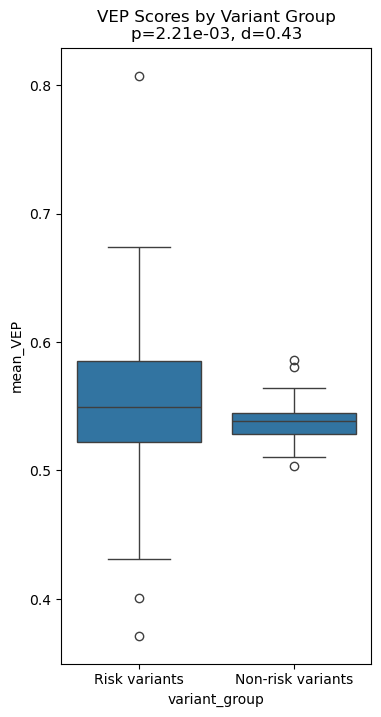

In [83]:
dat = pd.concat([
    # Risk variants - exclude zeros and large deletions
    clinvar_vs_wt[~clinvar_vs_wt.index.isin(large_del_rows)][risk_variants].replace(0, np.nan).mean(axis=1, skipna=True).reset_index(name="mean_VEP").assign(variant_group="Risk variants"),
    # Non-risk variants - exclude zeros and large deletions
    clinvar_vs_wt[~clinvar_vs_wt.index.isin(large_del_rows)][clinvar_vs_wt.columns.difference(risk_variants)].replace(0, np.nan).mean(axis=1, skipna=True).reset_index(name="mean_VEP").assign(variant_group="Non-risk variants")
], axis=0)
dat


# First ensure no duplicate labels in the data
dat = dat.reset_index(drop=True)

# Perform statistical test
from scipy import stats
# Handle NaN values by dropping them before statistical test
risk_data = dat[dat['variant_group'] == 'Risk variants']['mean_VEP'].dropna()
nonrisk_data = dat[dat['variant_group'] == 'Non-risk variants']['mean_VEP'].dropna()
stat, pval = stats.ttest_ind(risk_data, nonrisk_data)

# Calculate effect size (Cohen's d) manually since scipy.stats.cohens_d is not available
def cohens_d(x, y):
    nx = len(x)
    ny = len(y)
    dof = nx + ny - 2
    return (np.mean(x) - np.mean(y)) / np.sqrt(((nx-1)*np.var(x, ddof=1) + (ny-1)*np.var(y, ddof=1)) / dof)

effect_size = cohens_d(risk_data, nonrisk_data)

plt.figure(figsize=(4, 8))
sns.boxplot(data=dat, x="variant_group", y="mean_VEP")
plt.title(f'VEP Scores by Variant Group\np={pval:.2e}, d={effect_size:.2f}')

In [253]:
gwas_vep["is_risk_variant"] = gwas_vep["mutant"].isin(risk_variants)

In [257]:
gwas_vep["is_risk_variant"].value_counts() / gwas_vep.shape[0] 
 

is_risk_variant
False    0.9375
True     0.0625
Name: count, dtype: float64

In [102]:
gwas_vep.groupby(["clinsig","is_sig"])["site"].nunique()

clinsig  is_sig
benign   False     11
         True       3
path     False      1
         True       1
Name: site, dtype: int64

| rs_id       | chr | cytoband | position | ref_allele | alt_allele | freq_a1 | freq_a2 | odds_ratio | p_value    | beta    | se_beta  |
|-------------|-----|----------|----------|------------|------------|---------|---------|------------|------------|---------|----------|
| rs375280428 | 17  | 17q21.2  | 39254142 | G          | A          | 0.48    | 0.67    | 1.16       | 1.87E-09   | 1.15    | 2.90E-05 |
| rs58117746  | 17  | 17q21.2  | 39305775 | TGGCAGCAGCTGGGGC | T | 0.39    | 0.60    | 1.18       | 4.33E-10   | 1.15    | 7.72E-05 |
| rs11079012  | 17  | 17q21.2  | 39912880 | C          | G          | 0.69    | 0.66    | 0.86       | 7.06E-09   | 0.86    | 2.35E-05 |
| rs5820435   | 17  | 17q21.2  | 39961558 | C          | A          | 0.55    | 0.51    | 1.22       | 9.55E-12   | 1.17    | 2.72E-05 |

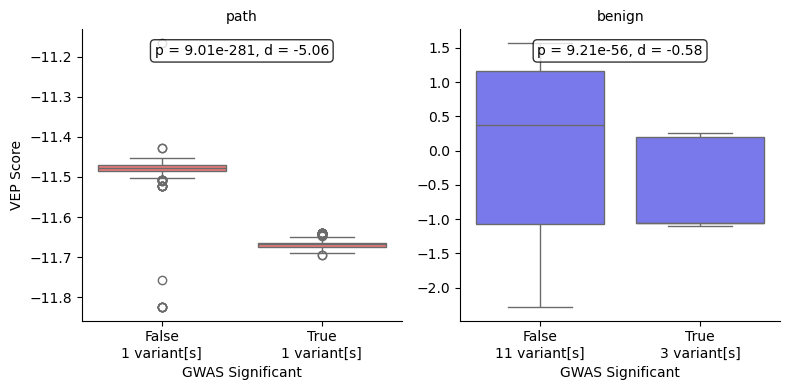

In [ ]:
gwas_vep["is_sig"] = gwas_vep["onco_icogs_bc_pval"] < 0.05
g = sns.FacetGrid(gwas_vep, col="clinsig", col_wrap=2, height=4, aspect=1, sharey=False, sharex=False)
g.map_dataframe(sns.boxplot, x="is_sig", y="VEP", hue="clinsig", palette=utils.get_clinsig_palette())
g.set_titles(col_template="{col_name}")
g.set_axis_labels("GWAS Significant", "VEP Score")

# Add n= counts and statistical test results under x-axis tick labels
for ax in g.axes.flat:
    # Get current tick positions and labels
    current_ticks = ax.get_xticks()
    current_labels = ax.get_xticklabels()
    
    # Get the clinical significance for this subplot
    clinsig = ax.get_title()
    
    # Filter data for this clinical significance
    subplot_data = gwas_vep[gwas_vep['clinsig'] == clinsig]
    
    # Perform statistical test if we have both groups
    if len(subplot_data['is_sig'].unique()) == 2:
        sig_data = subplot_data[subplot_data['is_sig'] == True]['VEP'].dropna()
        nonsig_data = subplot_data[subplot_data['is_sig'] == False]['VEP'].dropna()
        
        if len(sig_data) > 0 and len(nonsig_data) > 0:
            stat, pval = stats.ttest_ind(sig_data, nonsig_data)
            # Calculate effect size
            effect_size = cohens_d(sig_data, nonsig_data)
            pval_text = f"p = {pval:.2e}, d = {effect_size:.2f}"
        else:
            pval_text = "Insufficient data"
    else:
        pval_text = "Single group"
    
    # Create new labels with counts and p-values
    new_labels = []
    for i, tick in enumerate(current_labels):
        is_sig = tick.get_text()
        # Count data points for this combination
        count = gwas_vep[(gwas_vep['is_sig'] == (is_sig == "True")) & (gwas_vep['clinsig'] == clinsig)]["site"].nunique()
        new_labels.append(f"{is_sig}\n{count} variant(s)")
    
    # Set ticks and labels properly
    ax.set_xticks(current_ticks)
    ax.set_xticklabels(new_labels)
    
    # Add p-value text to subplot
    ax.text(0.5, 0.95, pval_text, transform=ax.transAxes, 
            ha='center', va='top', bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))

plt.tight_layout()
plt.show()

In [85]:
log_x = False
dat = gwas_vep.merge(clinvar_vs_wt[risk_variants].max(axis=1, skipna=True).reset_index(name="mean_VEP"))
for col in ["onco_bc_p", "onco_bc_beta", "onco_oc_p","onco_oc_beta", "icogs2_bc_beta","icogs2_oc_beta", "onco_icogs_bc_effect","onco_icogs_bc_pval","onco_icogs_oc_pval","onco_icogs_oc_effect"]:
    
    if log_x:
        x_data = np.log10(dat[col])
    else:
        x_data = dat[col]

    sns.scatterplot(data=dat, x=x_data, y="mean_VEP", hue="clinsig")
    plt.show()


MergeError: No common columns to perform merge on. Merge options: left_on=None, right_on=None, left_index=False, right_index=False

## UniProt Annotations

In [57]:
seqs = up.get_seqs("P38398")
seqs

/home/schilder/.conda/envs/esm2/lib/python3.13/site-packages/Bio/SeqIO/UniprotIO.py:65: BiopythonDeprecationWarning: Opening a UniProt XML file in text mode is deprecated, as it may lead to garbled characters. We recommend opening the file in binary mode; parsing UniProt XML files opened in text mode will no longer be supported in a future release of Biopython.
  warnings.warn(


[Seq('MDLSALRVEEVQNVINAMQKILECPICLELIKEPVSTKCDHIFCKFCMLKLLNQ...SHY')]

In [58]:
features_df = up.get_features("P38398")
features_df.head()

,id,type,start,end,description,evidence,original,variation,ref,length
0,PRO_0000055830,chain,0,1863,Breast cancer type 1 susceptibility protein,NaN,NaN,NaN,NaN,1863
1,<unknown id>,domain,1641,1736,BRCT 1,2,NaN,NaN,NaN,95
2,<unknown id>,domain,1755,1855,BRCT 2,2,NaN,NaN,NaN,100
3,<unknown id>,zinc finger region,23,65,RING-type,3,NaN,NaN,NaN,42
4,<unknown id>,region of interest,229,270,Disordered,4,NaN,NaN,NaN,41


In [27]:
# Transform VEP data from haplotype- to sample-level
vep_prot = vep_df[vep_df['protein'] == "NP_009225.1"].merge(haps_to_samples, on=["haplotype"], how="left")

rm_cols = ["sample","haplotype","is_ref","Super Population","Population","Gender","VEP"]
mutant_df = vep_prot.drop(columns=rm_cols).drop_duplicates()
# mutant_df = mutant_df.groupby([col for col in mutant_df.columns if col != 'VEP']).agg({"VEP":"mean"}).reset_index()
mutant_df["mutant_cluster"] = mutant_df["mutant"].map(variant_to_cluster)
# Count unique variants per cluster
cluster_variant_counts = mutant_df.groupby('mutant_cluster')['mutant'].nunique().reset_index()
cluster_variant_counts.columns = ['mutant_cluster', 'mutants_per_cluster']

# Merge with original dataframe
mutant_df = mutant_df.merge(cluster_variant_counts, on='mutant_cluster', how='left')

mutant_df


,protein,protein_sequence,mutant,mutated_sequence,DMS_bin_score,scoring_strategy,model_location,variant_set,ENSP,ENST,mutant_in_haplotype,#CHROM,POS,ID,REF,ALT,QUAL,FILTER,#Uploaded_variation,Location,Allele,Gene,Feature,Feature_type,Consequence,cDNA_position,CDS_position,Protein_position,Amino_acids,Codons,Existing_variation,IMPACT,DISTANCE,STRAND,FLAGS,REFSEQ_MATCH,REFSEQ_OFFSET,GIVEN_REF,USED_REF,BAM_EDIT,HGVSc,HGVSp,HGVS_OFFSET,AF_ESP,AF_EXAC,ALLELEID,CLNDISDB,CLNDN,CLNHGVS,CLNREVSTAT,CLNSIG,CLNSIGCONF,CLNVC,CLNVCSO,GENEINFO,MC,ORIGIN,RS,AF_TGP,CLNVI,CLNDISDBINCL,CLNDNINCL,CLNSIGINCL,EVH_epistatic,EVH_independent,ESM1V_ensemble_mean,Tranception,model_count,clinsig,ENST_haplosaurus,mutant_cluster,mutants_per_cluster
0,NP_009225.1,MDLSALRVEEVQNVINAMQKILECPICLELIKEPVSTKCDHIFCKF...,H1860Q,MDLSALRVEEVQNVINAMQKILECPICLELIKEPVSTKCDHIFCKF...,Benign,masked-marginals,esm2_t33_650M_UR50D,clinical_ProteinGym_substitutions,ENSP00000350283,ENST00000357654,False,17,43045690,1748423,G,T,.,PASS,1748423,17:43045690,T,672,NM_007294.4,Transcript,missense_variant,5693,5580,1860,H/Q,caC/caA,-,MODERATE,-,-1,-,-,-,G,G,-,NM_007294.4:c.5580C>A,NP_009225.1:p.His1860Gln,-,NaN,NaN,1806671,"MONDO:MONDO:0015356,MeSH:D009386,MedGen:C00276...",Hereditary_cancer-predisposing_syndrome,NC_000017.11:g.43045690G>T,"criteria_provided,_single_submitter",Likely_benign,NaN,single_nucleotide_variant,SO:0001483,BRCA1:672,"SO:0001583|missense_variant,SO:0001619|non-cod...",1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.632517,NaN,5,likely_benign,ENST00000357654,2,6
1,NP_009225.1,MDLSALRVEEVQNVINAMQKILECPICLELIKEPVSTKCDHIFCKF...,P1859R,MDLSALRVEEVQNVINAMQKILECPICLELIKEPVSTKCDHIFCKF...,Benign,masked-marginals,esm2_t33_650M_UR50D,clinical_ProteinGym_substitutions,ENSP00000350283,ENST00000357654,False,17,43045694,55634,G,C,.,PASS,55634,17:43045694,C,672,NM_007294.4,Transcript,missense_variant,5689,5576,1859,P/R,cCc/cGc,-,MODERATE,-,-1,-,-,-,G,G,-,NM_007294.4:c.5576C>G,NP_009225.1:p.Pro1859Arg,-,NaN,0.00002,70301,"MedGen:CN517202|MONDO:MONDO:0015356,MeSH:D0093...",not_provided|Hereditary_cancer-predisposing_sy...,NC_000017.11:g.43045694G>C,reviewed_by_expert_panel,Benign,NaN,single_nucleotide_variant,SO:0001483,BRCA1:672,"SO:0001583|missense_variant,SO:0001619|non-cod...",1,80357322,NaN,BRCA1-HCI:BRCA1_00098|ClinGen:CA003729,NaN,NaN,NaN,NaN,NaN,-0.490676,NaN,5,benign,ENST00000357654,57,11
2,NP_009225.1,MDLSALRVEEVQNVINAMQKILECPICLELIKEPVSTKCDHIFCKF...,I1858L,MDLSALRVEEVQNVINAMQKILECPICLELIKEPVSTKCDHIFCKF...,Benign,masked-marginals,esm2_t33_650M_UR50D,clinical_ProteinGym_substitutions,ENSP00000350283,ENST00000357654,False,17,43045698,183951,T,G,.,PASS,183951,17:43045698,G,672,NM_007294.4,Transcript,missense_variant,5685,5572,1858,I/L,Atc/Ctc,-,MODERATE,-,-1,-,-,-,T,T,-,NM_007294.4:c.5572A>C,NP_009225.1:p.Ile1858Leu,-,NaN,0.00006,184864,"MONDO:MONDO:0015356,MeSH:D009386,MedGen:C00276...",Hereditary_cancer-predisposing_syndrome|not_sp...,NC_000017.11:g.43045698T>G,reviewed_by_expert_panel,Benign,NaN,single_nucleotide_variant,SO:0001483,BRCA1:672,"SO:0001583|missense_variant,SO:0001619|non-cod...",1,765656957,NaN,BRCA1-HCI:BRCA1_00097|ClinGen:CA003726,NaN,NaN,NaN,NaN,NaN,0.791910,NaN,5,benign,ENST00000357654,60,64
3,NP_009225.1,MDLSALRVEEVQNVINAMQKILECPICLELIKEPVSTKCDHIFCKF...,P1856S,MDLSALRVEEVQNVINAMQKILECPICLELIKEPVSTKCDHIFCKF...,Benign,masked-marginals,esm2_t33_650M_UR50D,clinical_ProteinGym_substitutions,ENSP00000350283,ENST00000357654,False,17,43045704,55632,G,A,.,PASS,55632,17:43045704,A,672,NM_007294.4,Transcript,missense_variant,5679,5566,1856,P/S,Ccc/Tcc,-,MODERATE,-,-1,-,-,-,G,G,-,NM_007294.4:c.5566C>T,NP_009225.1:p.Pro1856Ser,-,NaN,0.00002,70299,"MONDO:MONDO:0015356,MeSH:D009386,MedGen:C00276...",Hereditary_cancer-predisposing_syndrome|Heredi...,NC_000017.11:g.43045704G>A,"criteria_provided,_multiple_submitters,_no_con...",Likely_benign,NaN,single_nucleotide_variant,SO:0001483,BRCA1:672,"SO:0001583|missense_variant,SO:0001619|non-cod...",1,80357274,NaN,ClinGen:CA003722,NaN,N

In [ ]:
records = up.import_uniprot("P38398")
seqs = up.get_seqs(records)
seqs

/home/schilder/.conda/envs/esm2/lib/python3.13/site-packages/Bio/SeqIO/UniprotIO.py:65: BiopythonDeprecationWarning: Opening a UniProt XML file in text mode is deprecated, as it may lead to garbled characters. We recommend opening the file in binary mode; parsing UniProt XML files opened in text mode will no longer be supported in a future release of Biopython.
  warnings.warn(


[Seq('MDLSALRVEEVQNVINAMQKILECPICLELIKEPVSTKCDHIFCKFCMLKLLNQ...SHY')]

In [ ]:
/api/v1/uniprot/summary/{uniprot_acc}

Cluster 68 has 11 unique variants


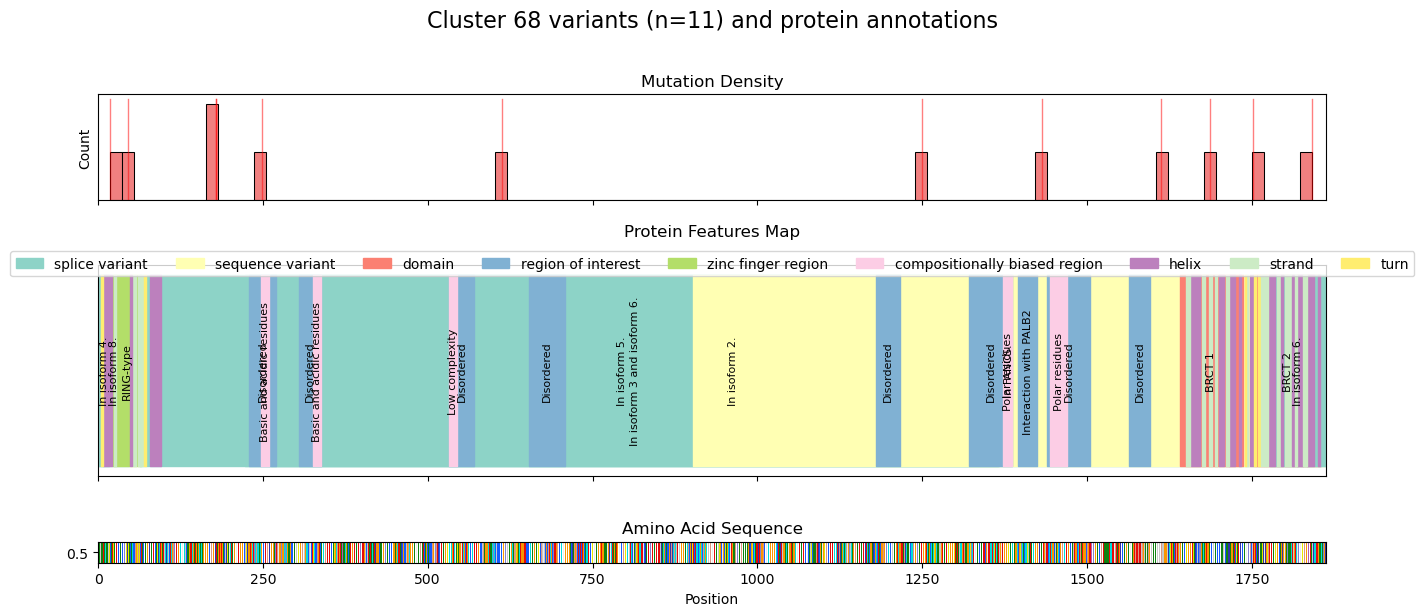

In [59]:

include_types = None
min_length = 2
exclude_types = ["chain",]
max_len = features_df.loc[features_df["type"] == "chain", "end"][0]


mutant_df = mutant_df.sort_values('mutants_per_cluster', ascending=False)
cluster_id = mutant_df["mutant_cluster"].unique()[9]
muts = mutant_df.loc[mutant_df["mutant_cluster"] == cluster_id]
# Merge annotation data from EnsemblVEP
# muts = muts.merge(cv_annot, on="mutant", how="left")



print(f"Cluster {cluster_id} has {muts['mutants_per_cluster'].iloc[0]} unique variants")

seq = str(seqs[0])

plot_df = features_df.copy()
plot_df.sort_values("length",ascending=False, inplace=True)

if include_types is not None:
    plot_df = plot_df[plot_df["type"].str.contains("|".join(include_types))]

if min_length is not None:
    plot_df = plot_df[plot_df["length"] >= min_length]

if exclude_types is not None:
    plot_df = plot_df[~plot_df["type"].str.contains("|".join(exclude_types))]

# Create figure with three subplots
fig, (ax0, ax1, ax2) = plt.subplots(3, 1, figsize=(15, 6), height_ratios=[0.5, 1, 0.1], sharex=True)

# Add overall title
fig.suptitle(f'Cluster {cluster_id} variants (n={muts["mutants_per_cluster"].iloc[0]}) and protein annotations', fontsize=16, y=1.02)

# Plot mutations and KDE on top subplot
sns.histplot(data=muts, 
             x='Protein_position', ax=ax0, fill=True, alpha=0.3, bins=100, fc='lightcoral')
y_max = ax0.get_ylim()[1]  # Get the maximum y value once
for pos in muts['Protein_position']:
    ax0.plot([pos, pos], [0, y_max], color='red', alpha=0.5, linewidth=1)
ax0.set_yticks([])
ax0.set_title('Mutation Density')

# Plot features on middle subplot
colors = plt.cm.Set3(np.linspace(0, 1, len(plot_df['type'].unique())))
type_to_color = dict(zip(plot_df['type'].unique(), colors))
for _, feat in plot_df.iterrows():
    if pd.notna(feat['start']) and pd.notna(feat['end']):
        ax1.fill_between([feat['start'], feat['end']], 
                        [-0.1, -0.1], [0.1, 0.1],
                        color=type_to_color[feat['type']],
                        alpha=1,
                        label=feat['type'] if feat['type'] not in ax1.get_legend_handles_labels()[1] else "")
        
        # Add description label if it exists
        if 'description' in feat and pd.notna(feat['description']):
            mid_point = (feat['start'] + feat['end']) / 2
            ax1.text(mid_point, 0, feat['description'],
                    rotation=90, ha='center', va='center',
                    fontsize=8)

# Define amino acid colors based on properties
aa_colors = {
    'A': '#C8C8C8',  # Alanine - Gray
    'C': '#E6E600',  # Cysteine - Yellow
    'D': '#E60A0A',  # Aspartic acid - Red
    'E': '#E60A0A',  # Glutamic acid - Red
    'F': '#3232AA',  # Phenylalanine - Blue
    'G': '#EBEBEB',  # Glycine - Light gray
    'H': '#8282D2',  # Histidine - Light blue
    'I': '#0F820F',  # Isoleucine - Green
    'K': '#145AFF',  # Lysine - Blue
    'L': '#0F820F',  # Leucine - Green
    'M': '#E6E600',  # Methionine - Yellow
    'N': '#00DCDC',  # Asparagine - Cyan
    'P': '#DC9682',  # Proline - Pink
    'Q': '#00DCDC',  # Glutamine - Cyan
    'R': '#145AFF',  # Arginine - Blue
    'S': '#FA9600',  # Serine - Orange
    'T': '#FA9600',  # Threonine - Orange
    'V': '#0F820F',  # Valine - Green
    'W': '#B45AB4',  # Tryptophan - Purple
    'Y': '#3232AA'   # Tyrosine - Blue
}

# Plot amino acids on bottom subplot
if seq:
    for i, aa in enumerate(seq):
        ax2.add_patch(plt.Rectangle((i-0.4, 0), 0.8, 1, 
                                  facecolor=aa_colors.get(aa, '#FFFFFF'),
                                  linewidth=0.1))
    ax2.set_ylim(0, 1)
    ax2.set_yticks([0.5])
    ax2.set_title('Amino Acid Sequence', y=1)
else:
    print("No sequence found")
    ax2.plot([0, max_len], [0.5, 0.5], 'k-', alpha=0.5, linewidth=5, label='Sequence')

# Configure plot appearance
ax1.set_title('Protein Features Map', y=1.1)
ax1.set_yticks([])
ax1.legend(bbox_to_anchor=(0.5, 1.1), loc='upper center', ncol=10)
ax1.set_xlim(0, max_len)

ax2.set_xlabel('Position')
ax2.set_xlim(0, max_len)

plt.tight_layout()

In [44]:
import pyranges as pr

# Convert mutations to pyranges format
mut_ranges = pr.PyRanges(
    chromosomes=["chr1"] * len(muts),
    starts=muts["Protein_position"] - 1,  # Convert to 0-based
    ends=muts["Protein_position"],
    strands=muts["STRAND"],
)
mut_ranges.mutant = muts["mutant"]  # Use mutant instead of Name

# Convert features to pyranges format
feature_ranges = pr.PyRanges(
    chromosomes=["chr1"] * len(features_df),
    starts=features_df["start"],
    ends=features_df["end"],
    strands=["+"] * len(features_df)
)
feature_ranges.feature_type = features_df["type"]  # Changed Name to feature_type

# Find overlaps between mutations and features
overlaps = mut_ranges.join(feature_ranges, suffix="_feature")

# Convert back to pandas DataFrame
overlap_df = overlaps.df
overlap_df

# Count overlaps per feature type
# feature_counts = overlap_df.groupby("feature_type")["feature_type"].count().reset_index()
# feature_counts.columns = ["feature_type", "overlap_count"]

# print("\nOverlap counts by feature type:")
# print(feature_counts.sort_values("overlap_count", ascending=False))

# # Add overlap information to muts DataFrame
# muts["overlapping_features"] = muts["mutant"].map(
#     overlap_df.groupby("mutant")["feature_type"].agg(list).to_dict()
# )


join: Strand data from other will be added as strand data to self.
If this is undesired use the flag apply_strand_suffix=False.
To turn off the warning set apply_strand_suffix to True or False.


,Chromosome,Start,End,Strand,mutant,Start_feature,End_feature,Strand_feature,feature_type
0,chr1,44,45,NaN,K45Q,0,1863,+,chain
1,chr1,44,45,NaN,K45Q,0,47,+,splice variant
2,chr1,44,45,NaN,K45Q,23,65,+,zinc finger region
3,chr1,44,45,NaN,K45Q,44,45,+,sequence variant
4,chr1,17,18,NaN,M18T,0,1863,+,chain
5,chr1,17,18,NaN,M18T,0,47,+,splice variant
6,chr1,17,18,NaN,M18T,7,21,+,helix
7,chr1,17,18,NaN,M18T,17,18,+,sequence variant
8,chr1,178,179,NaN,Y179C,0,1863,+,chain
9,chr1,178,179,NaN,Y179C,63,1863,+,splice variant


In [ ]:
features_df["type"].value_counts()

type
sequence variant                 170
modified residue                  30
mutagenesis site                  27
strand                            19
helix                             15
cross-link                        13
region of interest                 9
splice variant                     8
sequence conflict                  8
compositionally biased region      5
turn                               5
domain                             2
zinc finger region                 1
chain                              1
Name: count, dtype: int64

In [ ]:
# spliceai_cols = [x for x in muts.columns if x.startswith("SpliceAI_pred_D")]

# annot_cols  = [
#     #### CADD ####
#     "CADD_PHRED","CADD_RAW",

#     #### REVEL ####
#     "REVEL",

#     #### MaveDB ####
#    "MaveDB_score_mean", 
#    "MaveDB_score_abs_mean",
# #    "MaveDB_score_min",
# #    "MaveDB_score_max",


#     #### EVE ####
#     "EVE_SCORE",
    
#     #### ClinPred ####
#     "ClinPred",

#     #### RF ####
#     "rf_score",

#     #### AdaScore ####
#     "ada_score",

#     #### MaxEntScan ####
#     'MaxEntScan_diff',
    
#     #### LOEUF ####
#     "LOEUF",
    
#     #### AlphaMissense ####
#     "am_pathogenicity",

#     ### SpliceAI ####
#     *spliceai_cols,
#     #### OpenTargets ####
# #    "OpenTargets_l2g",


#     #### Allele Frequences ####
#     "gnomADe_AF","gnomADg_AF","AF_TGP",
#     "AllOfUs_gvs_all_af", "AllOfUs_gvs_max_af",

#     # "MOTIF_SCORE_CHANGE",

#     #### pHaplo ####
#     # "pHaplo" => "Probability of haploinsufficiency (deletion intolerance) of the affected gene",
#     # "pTriplo" => "Probability of triplosensitivity (duplication intolerance) of the affected gene"
#     "pHaplo",
#     "pTriplo",


#     ### Conservation ####
#     "SIFT_score",
#     "PolyPhen_score",
#     ]


#  # Create heatmap with protein position on x-axis and other features on y-axis
#  plt.figure(figsize=(15, 8))
#  sns.heatmap(cv_annot.loc[cv_annot["SYMBOL"] == "BRCA1" ,["Protein_position"]+[x for x in annot_cols if x in cv_annot.columns]].set_index("Protein_position").T
#             cmap='RdBu_r',
#             center=0,
#             annot=True,
#             fmt='.2f',
#             square=True)
#  plt.title('Feature Values by Protein Position')
#  plt.xlabel('Protein Position')
#  plt.ylabel('Features')
#  plt.tight_layout()